<a href="https://colab.research.google.com/github/prometricas/Ana_Suastegui_mx/blob/main/TRASSE_desc_corr_mejorado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TRASSE — Paso 4. Análisis descriptivo-correlacional

Cuaderno autocontenido para Google Colab. Trabaja con **`TRASSE_div3.xlsx`** y utiliza la diversificación como resultado ordinal con tres categorías: **No diversificado**, **Intermedia** y **Alta**.

El propósito es examinar la relación empírica entre la diversificación y los **componentes potenciales de capital humano, social, natural, físico y financiero**, además de conectividad territorial, covariables demográficas y contexto de vulnerabilidad.

No se construyen índices ni se estiman modelos econométricos en esta fase. Las variables que participan directamente en la construcción de la diversificación y los flujos de ingreso se excluyen de las pruebas principales para evitar relaciones mecánicas o simultaneidad evidente. Las asociaciones se interpretan como descriptivo-correlacionales y no como efectos causales.

## 0. Preparación del entorno

In [ ]:
# Verifico e instalo únicamente dependencias que pudieran faltar en Google Colab.
import importlib.util, subprocess, sys

paquetes = {
    "openpyxl": "openpyxl",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",
}
for modulo, paquete in paquetes.items():
    if importlib.util.find_spec(modulo) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete])

# Cargo las librerías de análisis.
from pathlib import Path
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.oneway import anova_oneway
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 80)
np.random.seed(20260808)

# Ajusto tamaños globales para que títulos, ejes y etiquetas sigan siendo legibles al exportar el cuaderno.
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "font.size": 10.5,
    "axes.titlesize": 11.5,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9,
})

print("Entorno preparado.")

Entorno preparado.


## 1. Carga del archivo y controles de coherencia

Al ejecutarse en Google Colab, la celda siguiente solicitará cargar **`TRASSE_div3.xlsx`** si el archivo todavía no está disponible en la sesión. Para reproducir exactamente los resultados incorporados en este cuaderno debe utilizarse esa versión del libro.

In [ ]:
# Busco primero el archivo en ubicaciones habituales; si no existe, solicito su carga en Colab.
NOMBRE_ARCHIVO = "TRASSE_div3.xlsx"
candidatos = [Path("/content") / NOMBRE_ARCHIVO, Path.cwd() / NOMBRE_ARCHIVO, Path("/mnt/data") / NOMBRE_ARCHIVO]
ruta = next((p for p in candidatos if p.exists()), None)

if ruta is None:
    try:
        from google.colab import files
        cargados = files.upload()
        if NOMBRE_ARCHIVO not in cargados:
            raise FileNotFoundError(f"Debe cargarse exactamente {NOMBRE_ARCHIVO}.")
        ruta = Path(NOMBRE_ARCHIVO)
    except ImportError as exc:
        raise FileNotFoundError(f"No se encontró {NOMBRE_ARCHIVO} en la sesión.") from exc

# Cargo únicamente las hojas necesarias para el análisis.
base = pd.read_excel(ruta, sheet_name="Base", engine="openpyxl")
diversif = pd.read_excel(ruta, sheet_name="Diversif", engine="openpyxl")

# Verifico la unidad de análisis antes de unir información.
assert base["ID_hogar"].is_unique, "La hoja Base no tiene una fila única por hogar."
assert diversif["ID_hogar"].is_unique, "La hoja Diversif no tiene una fila única por hogar."
assert len(base) == 129 and len(diversif) == 129, "Se esperaban 129 hogares en ambas hojas."

# Uno en relación 1:1 y conservo la etiqueta textual de diversificación de la hoja minimalista.
df = base.merge(
    diversif[["ID_hogar", "Diversificacion", "Fuentes_no_laborales_hogar"]],
    on="ID_hogar", how="left", validate="one_to_one", suffixes=("", "_div")
)

ORDEN_DIV = ["No diversificado", "Intermedia", "Alta"]
COD_DIV = {"No diversificado": 0, "Intermedia": 1, "Alta": 2}
df["_div_ord"] = df["Diversificacion"].map(COD_DIV)

# Creo una codificación interna de localidad solo para la prueba estadística; no modifica el Excel.
df["_Mandimbo"] = (df["Localidad"] == "Mandimbo").astype(int)

# Compruebo que la etiqueta de Diversif coincide con la codificación que ya existe en Base.
mapa_base = df["Diversificacion_ordinal"].map({0: "No diversificado", 1: "Intermedia", 2: "Alta"})
assert (mapa_base == df["Diversificacion"]).all(), "La diversificación no coincide entre Base y Diversif."

print(f"Archivo procesado: {ruta.name}")
print(f"Hogares: {len(df)} | IDs únicos: {df['ID_hogar'].nunique()}")
display(pd.crosstab(df["Diversificacion"], columns="n").reindex(ORDEN_DIV))

Archivo procesado: TRASSE_div3.xlsx
Hogares: 129 | IDs únicos: 129


col_0,n
Diversificacion,
No diversificado,35
Intermedia,53
Alta,41


### Criterios estadísticos de esta fase

Las comparaciones se realizan **siempre contra la diversificación**; no se calculan correlaciones indiscriminadas entre covariables o entre componentes de capital. Cada bloque temático se evalúa por separado para conservar una lectura sustantiva.

- Variables numéricas u ordinales: ANOVA cuando los diagnósticos lo permiten; Welch ante heterocedasticidad; Kruskal–Wallis cuando la escala o la distribución lo requieren.
- Variables binarias: chi-cuadrado de Pearson; cuando las frecuencias esperadas son pequeñas, se utiliza una versión permutacional.
- Dirección ordinal: correlación de Spearman entre el indicador y la codificación 0–1–2 de diversificación.
- Magnitud en binarias: V de Cramér con corrección de sesgo.
- Comparaciones post hoc: Mann–Whitney o Fisher según corresponda, con ajuste de Holm.
- Multiplicidad: Benjamini–Hochberg **dentro de cada bloque temático**. Por tanto, `q_FDR` no debe interpretarse como un ajuste único sobre los 65 contrastes del cuaderno.

Una asociación bivariada, aun con `q_FDR < 0.05`, no determina por sí sola la inclusión de una variable en un índice o modelo. La decisión posterior también depende de su función conceptual, redundancia, temporalidad y riesgo de simultaneidad.

In [ ]:
# Defino los bloques y las variables potencialmente utilizables en capitales o como covariables.
BLOQUES = {
    "Covariables demográficas y territoriales": {
        "numeric": ["Num_integrantes", "Edad_jefe", "Num_menores_15", "Num_adultos_15_64", "Num_65_o_mas", "Tasa_dependencia"],
        "binary": ["Jefatura_femenina", "_Mandimbo"],
    },
    "Capital humano": {
        "numeric": ["Nivel_educativo_jefe", "Nivel_educativo_max_hogar", "Nivel_educativo_prom_adultos", "Num_temas_capacitacion", "Num_capacitaciones_aplicadas"],
        "binary": ["Enfermedad_cronica", "Sin_servicio_medico", "Recibio_capacitacion"],
    },
    "Capital social": {
        "numeric": ["Num_organizaciones", "Num_beneficios_organizacion", "Asambleas_convocadas", "Asambleas_asistidas", "Num_familiares_apoyo"],
        "binary": ["Pertenece_organizacion", "Participa_comite", "Participa_tequio", "Aporta_fiesta", "Consultado_decisiones", "Confianza_representantes", "Red_apoyo_familiar", "Apoya_otros_hogares", "Existe_lider_comunitario", "Recibe_apoyo_institucional"],
    },
    "Conectividad territorial": {
        "numeric": ["Dist_carretera_km", "Dist_primer_lugar_compra_km"],
        "binary": ["Compra_fuera_comunidad"],
    },
    "Capital natural": {
        "numeric": ["Num_terrenos", "Superficie_parcelas_ha", "Num_recursos_naturales_usados", "Abundancia_percibida_prom"],
        "binary": ["Tiene_terreno", "Escasez_agua", "Buena_calidad_agua"],
    },
    "Capital físico": {
        "numeric": ["Num_activos_hogar", "Num_cuartos"],
        "binary": ["Vehiculo_propio", "Internet", "Drenaje_mejorado", "Usa_lena_cocinar", "Piso_firme", "Techo_concreto", "Paredes_concreto"],
    },
    "Capital financiero": {
        "numeric": [],
        "binary": ["Recibio_credito", "Credito_emergencia", "Tiene_ahorro", "Ahorro_emergencia"],
    },
    "Contexto de vulnerabilidad": {
        "numeric": ["Num_estresores"],
        "binary": ["Estresor_precios_bajos", "Estresor_pocos_compradores", "Estresor_altos_costos", "Estresor_clima", "Estresor_plagas", "Estresor_covid", "Estresor_temblor", "Estresor_huracan", "Estresor_otro", "Recibe_alerta"],
    },
}

ETIQUETAS = {
    "_Mandimbo": "Localidad: Mandimbo",
    "Num_integrantes": "Integrantes del hogar", "Edad_jefe": "Edad de la jefatura", "Jefatura_femenina": "Jefatura femenina",
    "Num_menores_15": "Menores de 15 años", "Num_adultos_15_64": "Adultos de 15–64 años", "Num_65_o_mas": "Personas de 65 años o más", "Tasa_dependencia": "Tasa de dependencia",
    "Nivel_educativo_jefe": "Nivel educativo de la jefatura", "Nivel_educativo_max_hogar": "Nivel educativo máximo del hogar", "Nivel_educativo_prom_adultos": "Nivel educativo promedio de adultos",
    "Enfermedad_cronica": "Enfermedad crónica", "Sin_servicio_medico": "Sin servicio médico", "Recibio_capacitacion": "Recibió capacitación",
    "Num_temas_capacitacion": "Número de temas de capacitación", "Num_capacitaciones_aplicadas": "Capacitaciones aplicadas",
    "Pertenece_organizacion": "Pertenece a organización", "Num_organizaciones": "Número de organizaciones", "Num_beneficios_organizacion": "Beneficios de organización",
    "Participa_comite": "Participa en comité", "Participa_tequio": "Participa en tequio", "Aporta_fiesta": "Aporta a fiesta comunitaria",
    "Asambleas_convocadas": "Asambleas convocadas", "Asambleas_asistidas": "Asambleas asistidas", "Consultado_decisiones": "Consultado en decisiones",
    "Confianza_representantes": "Confianza en representantes", "Red_apoyo_familiar": "Red de apoyo familiar", "Num_familiares_apoyo": "Familiares disponibles para apoyo",
    "Apoya_otros_hogares": "Apoya a otros hogares", "Existe_lider_comunitario": "Existe líder comunitario", "Recibe_apoyo_institucional": "Recibe apoyo institucional",
    "Dist_carretera_km": "Distancia a carretera (km)", "Dist_primer_lugar_compra_km": "Distancia al primer lugar de compra (km)", "Compra_fuera_comunidad": "Compra fuera de la comunidad",
    "Tiene_terreno": "Tiene terreno", "Num_terrenos": "Número de terrenos", "Superficie_parcelas_ha": "Superficie de parcelas (ha)",
    "Num_recursos_naturales_usados": "Recursos naturales usados", "Abundancia_percibida_prom": "Abundancia percibida promedio", "Escasez_agua": "Escasez de agua", "Buena_calidad_agua": "Buena calidad del agua",
    "Num_activos_hogar": "Número de activos del hogar", "Vehiculo_propio": "Vehículo propio", "Internet": "Internet", "Num_cuartos": "Número de cuartos", "Drenaje_mejorado": "Drenaje mejorado",
    "Usa_lena_cocinar": "Usa leña para cocinar", "Piso_firme": "Piso firme", "Techo_concreto": "Techo de concreto", "Paredes_concreto": "Paredes de concreto",
    "Recibio_credito": "Recibió crédito", "Credito_emergencia": "Acceso a crédito de emergencia", "Tiene_ahorro": "Tiene ahorro", "Ahorro_emergencia": "Ahorro disponible para emergencia",
    "Num_estresores": "Número de estresores", "Estresor_precios_bajos": "Estresor: precios bajos", "Estresor_pocos_compradores": "Estresor: pocos compradores", "Estresor_altos_costos": "Estresor: altos costos",
    "Estresor_clima": "Estresor: clima", "Estresor_plagas": "Estresor: plagas", "Estresor_covid": "Estresor: COVID-19", "Estresor_temblor": "Estresor: temblor", "Estresor_huracan": "Estresor: huracán", "Estresor_otro": "Otro estresor", "Recibe_alerta": "Recibe alertas",
}

# Mantengo por regla no paramétrica los conteos, proporciones discretas y escalas ordinales.
ORDINAL_CONTEO = {
    "Num_integrantes", "Num_menores_15", "Num_adultos_15_64", "Num_65_o_mas", "Tasa_dependencia",
    "Nivel_educativo_jefe", "Nivel_educativo_max_hogar", "Nivel_educativo_prom_adultos", "Num_temas_capacitacion", "Num_capacitaciones_aplicadas",
    "Num_organizaciones", "Num_beneficios_organizacion", "Asambleas_convocadas", "Asambleas_asistidas", "Num_familiares_apoyo",
    "Num_terrenos", "Num_recursos_naturales_usados", "Num_activos_hogar", "Num_cuartos", "Num_estresores"
}

VARIABLES_NUCLEO = []
for meta in BLOQUES.values():
    VARIABLES_NUCLEO.extend(meta["numeric"] + meta["binary"])
VARIABLES_NUCLEO = list(dict.fromkeys(VARIABLES_NUCLEO))

print(f"Variables incluidas en pruebas principales: {len(VARIABLES_NUCLEO)}")
print("No se ha creado ningún índice de capital.")

Variables incluidas en pruebas principales: 65
No se ha creado ningún índice de capital.


## 2. Funciones de contraste, magnitud de asociación y post hoc

In [ ]:
def _ptexto(p):
    if pd.isna(p): return ""
    return "<0.001" if p < 0.001 else f"{p:.3f}"

def cramers_v(tabla):
    """V de Cramér con corrección de sesgo para tablas pequeñas."""
    chi2 = stats.chi2_contingency(tabla, correction=False)[0]
    n = tabla.to_numpy().sum()
    r, k = tabla.shape
    phi2 = chi2 / n
    phi2c = max(0.0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rc = r - ((r - 1) ** 2) / max(n - 1, 1)
    kc = k - ((k - 1) ** 2) / max(n - 1, 1)
    den = max(1e-12, min(kc - 1, rc - 1))
    return float(np.sqrt(phi2c / den))

def chi2_permutacional(x, y, B=5000, seed=20260808):
    """Obtengo p por permutación con márgenes fijos y conteo NumPy para evitar aproximaciones frágiles."""
    xc, _ = pd.factorize(pd.Series(x), sort=True)
    yc, _ = pd.factorize(pd.Series(y), sort=True)
    r, k = int(xc.max() + 1), int(yc.max() + 1)
    obs_tab = np.bincount(xc * k + yc, minlength=r*k).reshape(r, k).astype(float)
    n = obs_tab.sum()
    esperada = np.outer(obs_tab.sum(axis=1), obs_tab.sum(axis=0)) / n
    obs = float(np.sum((obs_tab - esperada)**2 / esperada))
    rng = np.random.default_rng(seed)
    mayores = 0
    for _ in range(B):
        yp = rng.permutation(yc)
        tab = np.bincount(xc * k + yp, minlength=r*k).reshape(r, k)
        valor = float(np.sum((tab - esperada)**2 / esperada))
        mayores += valor >= obs - 1e-12
    return float((mayores + 1) / (B + 1)), obs

def prueba_numerica(variable):
    datos = df[[variable, "Diversificacion", "_div_ord"]].copy()
    datos[variable] = pd.to_numeric(datos[variable], errors="coerce")
    datos = datos.dropna()
    grupos = [datos.loc[datos["Diversificacion"] == g, variable].to_numpy() for g in ORDEN_DIV]
    if min(map(len, grupos)) < 3:
        return None

    # Decido entre familia paramétrica y no paramétrica usando escala y diagnósticos.
    usar_no_param = variable in ORDINAL_CONTEO
    normal = not usar_no_param
    if normal:
        for arr in grupos:
            if len(np.unique(arr)) <= 2 or stats.shapiro(arr).pvalue <= 0.05:
                normal = False
                break

    if normal:
        lev = stats.levene(*grupos, center="median")
        if lev.pvalue > 0.05:
            prueba = "ANOVA"
            rr = stats.f_oneway(*grupos)
            estad, p = float(rr.statistic), float(rr.pvalue)
        else:
            prueba = "Welch ANOVA"
            rr = anova_oneway(grupos, use_var="unequal", welch_correction=True)
            estad, p = float(rr.statistic), float(rr.pvalue)
    else:
        prueba = "Kruskal–Wallis"
        rr = stats.kruskal(*grupos)
        estad, p = float(rr.statistic), float(rr.pvalue)

    rho, p_rho = stats.spearmanr(datos[variable], datos["_div_ord"])
    desc = {}
    for g, arr in zip(ORDEN_DIV, grupos):
        q1, q3 = np.quantile(arr, [0.25, 0.75])
        desc[g] = f"{np.median(arr):.2f} [{q1:.2f}; {q3:.2f}]"

    return {
        "Variable": variable, "Indicador": ETIQUETAS.get(variable, variable), "Tipo": "Numérica/ordinal", "N": len(datos),
        **desc, "Prueba": prueba, "Estadistico": estad, "p": p, "rho_s": float(rho), "p_rho": float(p_rho), "V_Cramer": np.nan
    }

def prueba_binaria(variable):
    datos = df[[variable, "Diversificacion", "_div_ord"]].copy()
    datos[variable] = pd.to_numeric(datos[variable], errors="coerce")
    datos = datos.dropna()
    datos = datos[datos[variable].isin([0, 1])]
    tabla = pd.crosstab(datos[variable], datos["Diversificacion"]).reindex(index=[0, 1], columns=ORDEN_DIV, fill_value=0)
    chi2, p, _, esp = stats.chi2_contingency(tabla, correction=False)
    if (esp < 5).any():
        p, chi2 = chi2_permutacional(datos[variable], datos["Diversificacion"])
        prueba = "Chi² permutacional"
    else:
        prueba = "Chi² de Pearson"
    v = cramers_v(tabla)
    rho, p_rho = stats.spearmanr(datos[variable], datos["_div_ord"])
    desc = {}
    for g in ORDEN_DIV:
        s = datos.loc[datos["Diversificacion"] == g, variable]
        desc[g] = f"{100*s.mean():.1f}% ({int(s.sum())}/{len(s)})" if len(s) else "NA"
    return {
        "Variable": variable, "Indicador": ETIQUETAS.get(variable, variable), "Tipo": "Binaria", "N": len(datos),
        **desc, "Prueba": prueba, "Estadistico": float(chi2), "p": float(p), "rho_s": float(rho), "p_rho": float(p_rho), "V_Cramer": v
    }

def analizar_bloque(nombre):
    meta = BLOQUES[nombre]
    filas = []
    for v in meta["numeric"]:
        r = prueba_numerica(v)
        if r is not None: filas.append(r)
    for v in meta["binary"]:
        r = prueba_binaria(v)
        if r is not None: filas.append(r)
    tabla = pd.DataFrame(filas)
    tabla["q_FDR"] = multipletests(tabla["p"].to_numpy(), method="fdr_bh")[1]
    tabla["Magnitud"] = np.where(tabla["Tipo"].eq("Binaria"), tabla["V_Cramer"], tabla["rho_s"].abs())
    tabla = tabla.sort_values(["q_FDR", "Magnitud"], ascending=[True, False]).reset_index(drop=True)
    return tabla

def mostrar_tabla(tabla):
    cols = ["Variable", "Indicador", "N", "No diversificado", "Intermedia", "Alta", "Prueba", "p", "q_FDR", "rho_s", "V_Cramer"]
    salida = tabla[cols].copy()
    for c in ["p", "q_FDR"]:
        salida[c] = salida[c].map(_ptexto)
    for c in ["rho_s", "V_Cramer"]:
        salida[c] = salida[c].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")
    display(salida)

def _resumen_central(variable, tipo):
    """Obtengo prevalencias o medianas por nivel de diversificación para describir la forma observada."""
    vals = []
    for g in ORDEN_DIV:
        s = pd.to_numeric(df.loc[df["Diversificacion"] == g, variable], errors="coerce").dropna()
        vals.append(float(s.mean()) if tipo == "Binaria" else float(s.median()))
    return vals

def _forma_tres_niveles(vals, tipo, tol=1e-12):
    """Describe el patrón de tres resúmenes sin confundir igualdad de medianas con igualdad de distribuciones."""
    a, b, c = vals
    pref = "prevalencia" if tipo == "Binaria" else "mediana"
    if a <= b + tol and b <= c + tol and (c - a) > tol:
        if abs(a-b) <= tol:
            return f"{pref} igual en no diversificado e intermedia y mayor en alta"
        if abs(b-c) <= tol:
            return f"{pref} menor en no diversificado y equivalente en intermedia/alta"
        return f"gradiente creciente de {pref}"
    if a >= b - tol and b >= c - tol and (a - c) > tol:
        if abs(a-b) <= tol:
            return f"{pref} igual en no diversificado e intermedia y menor en alta"
        if abs(b-c) <= tol:
            return f"{pref} mayor en no diversificado y equivalente en intermedia/alta"
        return f"gradiente decreciente de {pref}"
    if b < min(a, c) - tol:
        if c > a + tol:
            return f"{pref} desciende en intermedia y alcanza su máximo en alta"
        if c < a - tol:
            return f"{pref} desciende en intermedia y se recupera parcialmente en alta"
        return f"patrón en U de {pref}"
    if b > max(a, c) + tol:
        return f"{pref} alcanza su máximo en la categoría intermedia"
    if c > max(a, b) + tol:
        return f"{pref} se concentra en diversificación alta"
    if a > max(b, c) + tol:
        return f"{pref} se concentra en hogares no diversificados"
    return f"patrón no monotónico de {pref}"

def interpretar_bloque(nombre, tabla):
    sig = tabla[tabla["q_FDR"] < 0.05]
    print(f"Lectura del bloque — {nombre}")
    if sig.empty:
        top = tabla.iloc[0]
        forma = _forma_tres_niveles(_resumen_central(top["Variable"], top["Tipo"]), top["Tipo"])
        print("• Ninguna asociación permanece por debajo de q_FDR = 0.05 después del ajuste dentro del bloque.")
        if top["p"] < 0.05:
            print(f"• {top['Indicador']} presenta una señal nominal (p={_ptexto(top['p'])}) que no se conserva tras el ajuste (q={_ptexto(top['q_FDR'])}); la forma descriptiva es: {forma}.")
        else:
            print(f"• La señal descriptiva de mayor magnitud corresponde a {top['Indicador']} (p={_ptexto(top['p'])}, q={_ptexto(top['q_FDR'])}); la forma observada es: {forma}.")
        print("• La ausencia de significación ajustada no constituye un criterio automático para descartar componentes conceptualmente pertinentes.")
        return
    print(f"• Asociaciones que permanecen con q_FDR < 0.05 dentro del bloque: {len(sig)}.")
    for _, r in sig.iterrows():
        vals = _resumen_central(r["Variable"], r["Tipo"])
        forma = _forma_tres_niveles(vals, r["Tipo"])
        if r["Tipo"] == "Binaria":
            print(f"• {r['Indicador']}: {r['No diversificado']} → {r['Intermedia']} → {r['Alta']}; V={r['V_Cramer']:.3f}, rho_s={r['rho_s']:.3f}; {forma}.")
        else:
            print(f"• {r['Indicador']}: medianas/RIC {r['No diversificado']} → {r['Intermedia']} → {r['Alta']}; rho_s={r['rho_s']:.3f}; {forma}.")
    print("• Estas diferencias describen asociación con la diversificación. La temporalidad, la selección y la posible simultaneidad se evaluarán antes de cualquier interpretación causal.")

def posthoc_significativos(tabla):
    filas = []
    pares = [(ORDEN_DIV[0], ORDEN_DIV[1]), (ORDEN_DIV[0], ORDEN_DIV[2]), (ORDEN_DIV[1], ORDEN_DIV[2])]
    for _, r in tabla[tabla["q_FDR"] < 0.05].iterrows():
        v = r["Variable"]
        pvals, temp = [], []
        for a, b in pares:
            dat = df.loc[df["Diversificacion"].isin([a, b]), ["Diversificacion", v]].dropna()
            if r["Tipo"] == "Binaria":
                tab = pd.crosstab(dat[v], dat["Diversificacion"]).reindex(index=[0, 1], columns=[a, b], fill_value=0)
                _, pv = stats.fisher_exact(tab.to_numpy())
                prueba = "Fisher"
            else:
                x = dat.loc[dat["Diversificacion"] == a, v]
                y = dat.loc[dat["Diversificacion"] == b, v]
                _, pv = stats.mannwhitneyu(x, y, alternative="two-sided")
                prueba = "Mann–Whitney"
            pvals.append(pv)
            temp.append([v, ETIQUETAS.get(v, v), f"{a} vs {b}", prueba, pv])
        ajust = multipletests(pvals, method="holm")[1]
        for fila, ph in zip(temp, ajust):
            fila.append(ph)
            filas.append(fila)
    if not filas:
        print("No corresponde calcular post hoc con el umbral definido.")
        return
    ph = pd.DataFrame(filas, columns=["Variable", "Indicador", "Comparacion", "Prueba", "p", "p_Holm"])
    ph["p"] = ph["p"].map(_ptexto); ph["p_Holm"] = ph["p_Holm"].map(_ptexto)
    display(ph)

## 3. Completitud de los componentes analizados

Antes de comparar niveles de diversificación se verifica si la ausencia de datos está concentrada en alguna categoría. Los vacíos estructurales de `Dist_terreno_km` y `Dist_compra_externa_min_km` no se tratan aquí como faltantes; se estudian posteriormente dentro de los hogares para los que esas distancias son aplicables.

In [ ]:
filas_missing = []
for v in VARIABLES_NUCLEO:
    if v == "_Mandimbo":
        continue
    miss = df[v].isna().astype(int)
    if miss.sum() == 0:
        continue
    tmp = pd.DataFrame({"miss": miss, "Diversificacion": df["Diversificacion"]})
    tabla = pd.crosstab(tmp["miss"], tmp["Diversificacion"]).reindex(index=[0,1], columns=ORDEN_DIV, fill_value=0)
    p, chi = chi2_permutacional(tmp["miss"], tmp["Diversificacion"], B=3000)
    fila = {"Variable": v, "Indicador": ETIQUETAS.get(v,v), "Faltantes_total": int(miss.sum()), "p": p}
    for g in ORDEN_DIV:
        s = tmp.loc[tmp["Diversificacion"] == g, "miss"]
        fila[g] = f"{100*s.mean():.1f}% ({int(s.sum())}/{len(s)})"
    filas_missing.append(fila)

miss_tab = pd.DataFrame(filas_missing)
if not miss_tab.empty:
    miss_tab["q_FDR"] = multipletests(miss_tab["p"], method="fdr_bh")[1]
    ver = miss_tab[["Variable","Indicador","Faltantes_total","No diversificado","Intermedia","Alta","p","q_FDR"]].copy()
    ver["p"] = ver["p"].map(_ptexto); ver["q_FDR"] = ver["q_FDR"].map(_ptexto)
    display(ver)
    if (miss_tab["q_FDR"] < 0.05).any():
        print("Se detecta faltante diferencial por diversificación en al menos un indicador; debe considerarse en el diseño de modelos posteriores.")
    else:
        print("No se detecta concentración estadísticamente diferenciada de faltantes por nivel de diversificación después del ajuste FDR.")
else:
    print("No hay faltantes en las variables del núcleo analítico.")

,Variable,Indicador,Faltantes_total,No diversificado,Intermedia,Alta,p,q_FDR
0,Tasa_dependencia,Tasa de dependencia,4,5.7% (2/35),1.9% (1/53),2.4% (1/41),0.679,1.000
1,Jefatura_femenina,Jefatura femenina,1,0.0% (0/35),1.9% (1/53),0.0% (0/41),1.000,1.000
2,Sin_servicio_medico,Sin servicio médico,1,2.9% (1/35),0.0% (0/53),0.0% (0/41),0.290,0.701
3,Asambleas_convocadas,Asambleas convocadas,4,2.9% (1/35),5.7% (3/53),0.0% (0/41),0.300,0.701
4,Aporta_fiesta,Aporta a fiesta comunitaria,1,0.0% (0/35),1.9% (1/53),0.0% (0/41),1.000,1.000
5,Consultado_decisiones,Consultado en decisiones,1,2.9% (1/35),0.0% (0/53),0.0% (0/41),0.263,0.701
6,Confianza_representantes,Confianza en representantes,1,2.9% (1/35),0.0% (0/53),0.0% (0/41),0.263,0.701
7,Apoya_otros_hogares,Apoya a otros hogares,2,2.9% (1/35),1.9% (1/53),0.0% (0/41),0.738,1.000
8,Recibe_apoyo_institucional,Recibe apoyo institucional,2,2.9% (1/35),0.0% (0/53),2.4% (1/41),0.521,1.000
9,Dist_carretera_km,Distancia a carretera (km),1,0.0% (0/35),1.9% (1/53),0.0% (0/41),1.000,1.000


No se detecta concentración estadísticamente diferenciada de faltantes por nivel de diversificación después del ajuste FDR.


## 4. Covariables demográficas y territoriales

Se examinan únicamente frente a la diversificación. La localidad se recodifica internamente como Mandimbo = 1 para cuantificar la asociación, sin crear una nueva variable en el archivo fuente.

In [ ]:
res_4 = analizar_bloque('Covariables demográficas y territoriales')
mostrar_tabla(res_4)
interpretar_bloque('Covariables demográficas y territoriales', res_4)
print("\nPost hoc para asociaciones con q_FDR < 0.05:")
posthoc_significativos(res_4)

,Variable,Indicador,N,No diversificado,Intermedia,Alta,Prueba,p,q_FDR,rho_s,V_Cramer
0,_Mandimbo,Localidad: Mandimbo,129,0.0% (0/35),1.9% (1/53),22.0% (9/41),Chi² permutacional,<0.001,0.003,0.326,0.343
1,Num_adultos_15_64,Adultos de 15–64 años,129,2.00 [1.50; 2.50],2.00 [2.00; 3.00],3.00 [2.00; 4.00],Kruskal–Wallis,<0.001,0.003,0.334,
2,Tasa_dependencia,Tasa de dependencia,125,0.67 [0.00; 1.00],0.50 [0.00; 1.00],0.18 [0.00; 0.50],Kruskal–Wallis,0.048,0.128,-0.218,
3,Num_integrantes,Integrantes del hogar,129,3.00 [2.00; 4.00],4.00 [3.00; 5.00],4.00 [3.00; 5.00],Kruskal–Wallis,0.093,0.186,0.185,
4,Num_menores_15,Menores de 15 años,129,0.00 [0.00; 2.00],1.00 [0.00; 2.00],0.00 [0.00; 1.00],Kruskal–Wallis,0.147,0.235,-0.123,
5,Edad_jefe,Edad de la jefatura,129,47.00 [36.00; 57.50],46.00 [35.00; 58.00],53.00 [42.00; 63.00],ANOVA,0.572,0.653,0.086,
6,Jefatura_femenina,Jefatura femenina,128,54.3% (19/35),53.8% (28/52),43.9% (18/41),Chi² de Pearson,0.565,0.653,-0.083,0.000
7,Num_65_o_mas,Personas de 65 años o más,129,0.00 [0.00; 1.00],0.00 [0.00; 1.00],0.00 [0.00; 0.00],Kruskal–Wallis,0.727,0.727,-0.056,


Lectura del bloque — Covariables demográficas y territoriales
• Asociaciones que permanecen con q_FDR < 0.05 dentro del bloque: 2.
• Localidad: Mandimbo: 0.0% (0/35) → 1.9% (1/53) → 22.0% (9/41); V=0.343, rho_s=0.326; gradiente creciente de prevalencia.
• Adultos de 15–64 años: medianas/RIC 2.00 [1.50; 2.50] → 2.00 [2.00; 3.00] → 3.00 [2.00; 4.00]; rho_s=0.334; mediana igual en no diversificado e intermedia y mayor en alta.
• Estas diferencias describen asociación con la diversificación. La temporalidad, la selección y la posible simultaneidad se evaluarán antes de cualquier interpretación causal.

Post hoc para asociaciones con q_FDR < 0.05:


,Variable,Indicador,Comparacion,Prueba,p,p_Holm
0,_Mandimbo,Localidad: Mandimbo,No diversificado vs Intermedia,Fisher,1.000,1.000
1,_Mandimbo,Localidad: Mandimbo,No diversificado vs Alta,Fisher,0.003,0.007
2,_Mandimbo,Localidad: Mandimbo,Intermedia vs Alta,Fisher,0.002,0.007
3,Num_adultos_15_64,Adultos de 15–64 años,No diversificado vs Intermedia,Mann–Whitney,0.009,0.018
4,Num_adultos_15_64,Adultos de 15–64 años,No diversificado vs Alta,Mann–Whitney,<0.001,<0.001
5,Num_adultos_15_64,Adultos de 15–64 años,Intermedia vs Alta,Mann–Whitney,0.096,0.096


## 5. Capital humano

Se conservan educación, salud y capacitación como componentes separados. Los niveles educativos son ordinales; no se interpretan como años de escolaridad.

In [ ]:
res_5 = analizar_bloque('Capital humano')
mostrar_tabla(res_5)
interpretar_bloque('Capital humano', res_5)
print("\nPost hoc para asociaciones con q_FDR < 0.05:")
posthoc_significativos(res_5)

,Variable,Indicador,N,No diversificado,Intermedia,Alta,Prueba,p,q_FDR,rho_s,V_Cramer
0,Recibio_capacitacion,Recibió capacitación,129,25.7% (9/35),22.6% (12/53),58.5% (24/41),Chi² de Pearson,<0.001,0.002,0.278,0.317
1,Num_temas_capacitacion,Número de temas de capacitación,129,0.00 [0.00; 0.50],0.00 [0.00; 0.00],1.00 [0.00; 2.00],Kruskal–Wallis,<0.001,0.002,0.291,
2,Num_capacitaciones_aplicadas,Capacitaciones aplicadas,129,0.00 [0.00; 0.00],0.00 [0.00; 0.00],1.00 [0.00; 2.00],Kruskal–Wallis,<0.001,0.002,0.291,
3,Enfermedad_cronica,Enfermedad crónica,129,34.3% (12/35),30.2% (16/53),56.1% (23/41),Chi² de Pearson,0.030,0.059,0.182,0.198
4,Nivel_educativo_jefe,Nivel educativo de la jefatura,129,3.00 [2.00; 4.00],2.00 [2.00; 3.00],2.00 [2.00; 3.00],Kruskal–Wallis,0.204,0.326,-0.154,
5,Nivel_educativo_max_hogar,Nivel educativo máximo del hogar,129,4.00 [3.00; 4.00],4.00 [3.00; 4.00],4.00 [3.00; 4.00],Kruskal–Wallis,0.410,0.468,0.114,
6,Sin_servicio_medico,Sin servicio médico,128,61.8% (21/34),75.5% (40/53),73.2% (30/41),Chi² de Pearson,0.364,0.468,0.089,0.006
7,Nivel_educativo_prom_adultos,Nivel educativo promedio de adultos,129,2.50 [2.00; 3.33],2.50 [2.00; 3.14],2.75 [2.00; 3.33],Kruskal–Wallis,0.973,0.973,-0.000,


Lectura del bloque — Capital humano
• Asociaciones que permanecen con q_FDR < 0.05 dentro del bloque: 3.
• Recibió capacitación: 25.7% (9/35) → 22.6% (12/53) → 58.5% (24/41); V=0.317, rho_s=0.278; prevalencia desciende en intermedia y alcanza su máximo en alta.
• Número de temas de capacitación: medianas/RIC 0.00 [0.00; 0.50] → 0.00 [0.00; 0.00] → 1.00 [0.00; 2.00]; rho_s=0.291; mediana igual en no diversificado e intermedia y mayor en alta.
• Capacitaciones aplicadas: medianas/RIC 0.00 [0.00; 0.00] → 0.00 [0.00; 0.00] → 1.00 [0.00; 2.00]; rho_s=0.291; mediana igual en no diversificado e intermedia y mayor en alta.
• Estas diferencias describen asociación con la diversificación. La temporalidad, la selección y la posible simultaneidad se evaluarán antes de cualquier interpretación causal.

Post hoc para asociaciones con q_FDR < 0.05:


,Variable,Indicador,Comparacion,Prueba,p,p_Holm
0,Recibio_capacitacion,Recibió capacitación,No diversificado vs Intermedia,Fisher,0.801,0.801
1,Recibio_capacitacion,Recibió capacitación,No diversificado vs Alta,Fisher,0.005,0.011
2,Recibio_capacitacion,Recibió capacitación,Intermedia vs Alta,Fisher,<0.001,0.002
3,Num_temas_capacitacion,Número de temas de capacitación,No diversificado vs Intermedia,Mann–Whitney,0.784,0.784
4,Num_temas_capacitacion,Número de temas de capacitación,No diversificado vs Alta,Mann–Whitney,0.003,0.006
5,Num_temas_capacitacion,Número de temas de capacitación,Intermedia vs Alta,Mann–Whitney,<0.001,0.001
6,Num_capacitaciones_aplicadas,Capacitaciones aplicadas,No diversificado vs Intermedia,Mann–Whitney,0.901,0.901
7,Num_capacitaciones_aplicadas,Capacitaciones aplicadas,No diversificado vs Alta,Mann–Whitney,0.002,0.005
8,Num_capacitaciones_aplicadas,Capacitaciones aplicadas,Intermedia vs Alta,Mann–Whitney,<0.001,0.003


## 6. Capital social

Se estudian organización, participación comunitaria, confianza, redes de apoyo y vinculación institucional sin agregarlos en un índice.

In [ ]:
res_6 = analizar_bloque('Capital social')
mostrar_tabla(res_6)
interpretar_bloque('Capital social', res_6)
print("\nPost hoc para asociaciones con q_FDR < 0.05:")
posthoc_significativos(res_6)

,Variable,Indicador,N,No diversificado,Intermedia,Alta,Prueba,p,q_FDR,rho_s,V_Cramer
0,Apoya_otros_hogares,Apoya a otros hogares,127,79.4% (27/34),75.0% (39/52),97.6% (40/41),Chi² de Pearson,0.011,0.166,0.202,0.236
1,Num_familiares_apoyo,Familiares disponibles para apoyo,129,1.00 [0.00; 3.00],2.00 [1.00; 5.00],3.00 [1.00; 5.00],Kruskal–Wallis,0.101,0.579,0.187,
2,Existe_lider_comunitario,Existe líder comunitario,129,14.3% (5/35),17.0% (9/53),31.7% (13/41),Chi² de Pearson,0.116,0.579,0.169,0.134
3,Num_organizaciones,Número de organizaciones,129,0.00 [0.00; 0.00],0.00 [0.00; 0.00],0.00 [0.00; 0.00],Kruskal–Wallis,0.277,0.677,0.116,
4,Confianza_representantes,Confianza en representantes,128,14.7% (5/34),20.8% (11/53),31.7% (13/41),Chi² de Pearson,0.197,0.677,0.157,0.099
5,Consultado_decisiones,Consultado en decisiones,128,41.2% (14/34),47.2% (25/53),58.5% (24/41),Chi² de Pearson,0.302,0.677,0.135,0.055
6,Pertenece_organizacion,Pertenece a organización,129,14.3% (5/35),13.2% (7/53),24.4% (10/41),Chi² de Pearson,0.316,0.677,0.109,0.047
7,Participa_tequio,Participa en tequio,129,62.9% (22/35),75.5% (40/53),70.7% (29/41),Chi² de Pearson,0.446,0.743,0.059,0.000
8,Red_apoyo_familiar,Red de apoyo familiar,129,68.6% (24/35),79.2% (42/53),80.5% (33/41),Chi² de Pearson,0.403,0.743,0.104,0.000
9,Asambleas_asistidas,Asambleas asistidas,129,0.00 [0.00; 0.50],0.00 [0.00; 1.00],0.00 [0.00; 1.00],Kruskal–Wallis,0.543,0.763,0.098,


Lectura del bloque — Capital social
• Ninguna asociación permanece por debajo de q_FDR = 0.05 después del ajuste dentro del bloque.
• Apoya a otros hogares presenta una señal nominal (p=0.011) que no se conserva tras el ajuste (q=0.166); la forma descriptiva es: prevalencia desciende en intermedia y alcanza su máximo en alta.
• La ausencia de significación ajustada no constituye un criterio automático para descartar componentes conceptualmente pertinentes.

Post hoc para asociaciones con q_FDR < 0.05:
No corresponde calcular post hoc con el umbral definido.


## 7. Conectividad territorial

Se analizan proximidad física y salida de la comunidad para compras. La distancia a compras externas se reserva para un análisis condicional porque solo existe para hogares que efectivamente compran fuera.

In [ ]:
res_7 = analizar_bloque('Conectividad territorial')
mostrar_tabla(res_7)
interpretar_bloque('Conectividad territorial', res_7)
print("\nPost hoc para asociaciones con q_FDR < 0.05:")
posthoc_significativos(res_7)

,Variable,Indicador,N,No diversificado,Intermedia,Alta,Prueba,p,q_FDR,rho_s,V_Cramer
0,Compra_fuera_comunidad,Compra fuera de la comunidad,128,8.6% (3/35),24.5% (13/53),42.5% (17/40),Chi² de Pearson,0.004,0.011,0.297,0.270
1,Dist_primer_lugar_compra_km,Distancia al primer lugar de compra (km),129,0.20 [0.10; 0.55],0.30 [0.10; 0.80],0.80 [0.10; 25.00],Kruskal–Wallis,0.028,0.042,0.212,
2,Dist_carretera_km,Distancia a carretera (km),128,1.00 [0.30; 1.10],1.00 [0.20; 1.00],1.00 [0.50; 1.50],Kruskal–Wallis,0.105,0.105,0.100,


Lectura del bloque — Conectividad territorial
• Asociaciones que permanecen con q_FDR < 0.05 dentro del bloque: 2.
• Compra fuera de la comunidad: 8.6% (3/35) → 24.5% (13/53) → 42.5% (17/40); V=0.270, rho_s=0.297; gradiente creciente de prevalencia.
• Distancia al primer lugar de compra (km): medianas/RIC 0.20 [0.10; 0.55] → 0.30 [0.10; 0.80] → 0.80 [0.10; 25.00]; rho_s=0.212; gradiente creciente de mediana.
• Estas diferencias describen asociación con la diversificación. La temporalidad, la selección y la posible simultaneidad se evaluarán antes de cualquier interpretación causal.

Post hoc para asociaciones con q_FDR < 0.05:


,Variable,Indicador,Comparacion,Prueba,p,p_Holm
0,Compra_fuera_comunidad,Compra fuera de la comunidad,No diversificado vs Intermedia,Fisher,0.089,0.154
1,Compra_fuera_comunidad,Compra fuera de la comunidad,No diversificado vs Alta,Fisher,0.001,0.004
2,Compra_fuera_comunidad,Compra fuera de la comunidad,Intermedia vs Alta,Fisher,0.077,0.154
3,Dist_primer_lugar_compra_km,Distancia al primer lugar de compra (km),No diversificado vs Intermedia,Mann–Whitney,0.830,0.830
4,Dist_primer_lugar_compra_km,Distancia al primer lugar de compra (km),No diversificado vs Alta,Mann–Whitney,0.022,0.057
5,Dist_primer_lugar_compra_km,Distancia al primer lugar de compra (km),Intermedia vs Alta,Mann–Whitney,0.019,0.057


## 8. Capital natural

Se utilizan tenencia y extensión de tierra, uso de recursos naturales y condiciones de agua. Siembra y superficie sembrada se mantienen fuera del núcleo por su proximidad con la actividad agrícola que participa en la diversificación.

In [ ]:
res_8 = analizar_bloque('Capital natural')
mostrar_tabla(res_8)
interpretar_bloque('Capital natural', res_8)
print("\nPost hoc para asociaciones con q_FDR < 0.05:")
posthoc_significativos(res_8)

,Variable,Indicador,N,No diversificado,Intermedia,Alta,Prueba,p,q_FDR,rho_s,V_Cramer
0,Superficie_parcelas_ha,Superficie de parcelas (ha),126,0.00 [0.00; 0.00],0.00 [0.00; 2.00],2.75 [0.00; 4.62],Kruskal–Wallis,<0.001,<0.001,0.384,
1,Num_terrenos,Número de terrenos,128,0.00 [0.00; 0.00],0.00 [0.00; 1.00],1.00 [0.00; 2.00],Kruskal–Wallis,<0.001,<0.001,0.373,
2,Tiene_terreno,Tiene terreno,129,22.9% (8/35),41.5% (22/53),65.9% (27/41),Chi² de Pearson,<0.001,0.002,0.334,0.311
3,Num_recursos_naturales_usados,Recursos naturales usados,129,3.00 [1.00; 4.00],3.00 [2.00; 4.00],4.00 [2.00; 6.00],Kruskal–Wallis,0.034,0.059,0.226,
4,Abundancia_percibida_prom,Abundancia percibida promedio,129,2.00 [1.12; 2.17],1.80 [1.33; 2.33],2.00 [1.67; 2.50],Kruskal–Wallis,0.333,0.467,0.098,
5,Escasez_agua,Escasez de agua,129,82.9% (29/35),86.8% (46/53),80.5% (33/41),Chi² de Pearson,0.705,0.822,-0.029,0.000
6,Buena_calidad_agua,Buena calidad del agua,129,88.6% (31/35),90.6% (48/53),92.7% (38/41),Chi² permutacional,0.936,0.936,0.054,0.000


Lectura del bloque — Capital natural
• Asociaciones que permanecen con q_FDR < 0.05 dentro del bloque: 3.
• Superficie de parcelas (ha): medianas/RIC 0.00 [0.00; 0.00] → 0.00 [0.00; 2.00] → 2.75 [0.00; 4.62]; rho_s=0.384; mediana igual en no diversificado e intermedia y mayor en alta.
• Número de terrenos: medianas/RIC 0.00 [0.00; 0.00] → 0.00 [0.00; 1.00] → 1.00 [0.00; 2.00]; rho_s=0.373; mediana igual en no diversificado e intermedia y mayor en alta.
• Tiene terreno: 22.9% (8/35) → 41.5% (22/53) → 65.9% (27/41); V=0.311, rho_s=0.334; gradiente creciente de prevalencia.
• Estas diferencias describen asociación con la diversificación. La temporalidad, la selección y la posible simultaneidad se evaluarán antes de cualquier interpretación causal.

Post hoc para asociaciones con q_FDR < 0.05:


,Variable,Indicador,Comparacion,Prueba,p,p_Holm
0,Superficie_parcelas_ha,Superficie de parcelas (ha),No diversificado vs Intermedia,Mann–Whitney,0.030,0.030
1,Superficie_parcelas_ha,Superficie de parcelas (ha),No diversificado vs Alta,Mann–Whitney,<0.001,<0.001
2,Superficie_parcelas_ha,Superficie de parcelas (ha),Intermedia vs Alta,Mann–Whitney,0.010,0.019
3,Num_terrenos,Número de terrenos,No diversificado vs Intermedia,Mann–Whitney,0.037,0.037
4,Num_terrenos,Número de terrenos,No diversificado vs Alta,Mann–Whitney,<0.001,<0.001
5,Num_terrenos,Número de terrenos,Intermedia vs Alta,Mann–Whitney,0.009,0.019
6,Tiene_terreno,Tiene terreno,No diversificado vs Intermedia,Fisher,0.107,0.107
7,Tiene_terreno,Tiene terreno,No diversificado vs Alta,Fisher,<0.001,<0.001
8,Tiene_terreno,Tiene terreno,Intermedia vs Alta,Fisher,0.023,0.046


## 9. Capital físico

Se examinan activos, vivienda, servicios e infraestructura doméstica. Los indicadores con muy poca variación deben interpretarse con cautela aunque se reporten.

In [ ]:
res_9 = analizar_bloque('Capital físico')
mostrar_tabla(res_9)
interpretar_bloque('Capital físico', res_9)
print("\nPost hoc para asociaciones con q_FDR < 0.05:")
posthoc_significativos(res_9)

,Variable,Indicador,N,No diversificado,Intermedia,Alta,Prueba,p,q_FDR,rho_s,V_Cramer
0,Num_cuartos,Número de cuartos,129,2.00 [2.00; 3.00],3.00 [2.00; 4.00],3.00 [2.00; 4.00],Kruskal–Wallis,0.077,0.615,0.200,
1,Usa_lena_cocinar,Usa leña para cocinar,129,74.3% (26/35),84.9% (45/53),90.2% (37/41),Chi² de Pearson,0.164,0.615,0.163,0.112
2,Piso_firme,Piso firme,129,91.4% (32/35),81.1% (43/53),90.2% (37/41),Chi² permutacional,0.277,0.615,-0.003,0.066
3,Techo_concreto,Techo de concreto,129,28.6% (10/35),43.4% (23/53),41.5% (17/41),Chi² de Pearson,0.344,0.615,0.095,0.031
4,Drenaje_mejorado,Drenaje mejorado,129,91.4% (32/35),98.1% (52/53),95.1% (39/41),Chi² permutacional,0.365,0.615,0.059,0.030
5,Vehiculo_propio,Vehículo propio,129,25.7% (9/35),35.8% (19/53),24.4% (10/41),Chi² de Pearson,0.410,0.615,-0.019,0.000
6,Internet,Internet,129,51.4% (18/35),56.6% (30/53),63.4% (26/41),Chi² de Pearson,0.568,0.731,0.093,0.000
7,Num_activos_hogar,Número de activos del hogar,129,8.00 [6.00; 9.00],8.00 [6.00; 9.00],8.00 [6.00; 10.00],Kruskal–Wallis,0.875,0.954,0.014,
8,Paredes_concreto,Paredes de concreto,129,57.1% (20/35),60.4% (32/53),58.5% (24/41),Chi² de Pearson,0.954,0.954,0.009,0.000


Lectura del bloque — Capital físico
• Ninguna asociación permanece por debajo de q_FDR = 0.05 después del ajuste dentro del bloque.
• La señal descriptiva de mayor magnitud corresponde a Número de cuartos (p=0.077, q=0.615); la forma observada es: mediana menor en no diversificado y equivalente en intermedia/alta.
• La ausencia de significación ajustada no constituye un criterio automático para descartar componentes conceptualmente pertinentes.

Post hoc para asociaciones con q_FDR < 0.05:
No corresponde calcular post hoc con el umbral definido.


## 10. Capital financiero

Se utilizan acceso a crédito y capacidad de ahorro. Los montos de ingreso no se incorporan como capital financiero.

In [ ]:
res_10 = analizar_bloque('Capital financiero')
mostrar_tabla(res_10)
interpretar_bloque('Capital financiero', res_10)
print("\nPost hoc para asociaciones con q_FDR < 0.05:")
posthoc_significativos(res_10)

,Variable,Indicador,N,No diversificado,Intermedia,Alta,Prueba,p,q_FDR,rho_s,V_Cramer
0,Tiene_ahorro,Tiene ahorro,129,45.7% (16/35),17.0% (9/53),41.5% (17/41),Chi² de Pearson,0.006,0.026,-0.015,0.251
1,Ahorro_emergencia,Ahorro disponible para emergencia,129,45.7% (16/35),22.6% (12/53),41.5% (17/41),Chi² de Pearson,0.048,0.095,-0.019,0.178
2,Recibio_credito,Recibió crédito,129,17.1% (6/35),32.1% (17/53),24.4% (10/41),Chi² de Pearson,0.285,0.379,0.054,0.062
3,Credito_emergencia,Acceso a crédito de emergencia,129,77.1% (27/35),75.5% (40/53),68.3% (28/41),Chi² de Pearson,0.632,0.632,-0.079,0.000


Lectura del bloque — Capital financiero
• Asociaciones que permanecen con q_FDR < 0.05 dentro del bloque: 1.
• Tiene ahorro: 45.7% (16/35) → 17.0% (9/53) → 41.5% (17/41); V=0.251, rho_s=-0.015; prevalencia desciende en intermedia y se recupera parcialmente en alta.
• Estas diferencias describen asociación con la diversificación. La temporalidad, la selección y la posible simultaneidad se evaluarán antes de cualquier interpretación causal.

Post hoc para asociaciones con q_FDR < 0.05:


,Variable,Indicador,Comparacion,Prueba,p,p_Holm
0,Tiene_ahorro,Tiene ahorro,No diversificado vs Intermedia,Fisher,0.007,0.021
1,Tiene_ahorro,Tiene ahorro,No diversificado vs Alta,Fisher,0.817,0.817
2,Tiene_ahorro,Tiene ahorro,Intermedia vs Alta,Fisher,0.011,0.022


## 11. Contexto de vulnerabilidad

Los estresores se mantienen como contexto y no como capital. El conteo resume exposición; las dummies distinguen el tipo de estresor y no se plantean para entrar simultáneamente en una misma especificación futura.

In [ ]:
res_11 = analizar_bloque('Contexto de vulnerabilidad')
mostrar_tabla(res_11)
interpretar_bloque('Contexto de vulnerabilidad', res_11)
print("\nPost hoc para asociaciones con q_FDR < 0.05:")
posthoc_significativos(res_11)

,Variable,Indicador,N,No diversificado,Intermedia,Alta,Prueba,p,q_FDR,rho_s,V_Cramer
0,Estresor_altos_costos,Estresor: altos costos,128,17.6% (6/34),39.6% (21/53),31.7% (13/41),Chi² de Pearson,0.097,0.517,0.102,0.144
1,Estresor_covid,Estresor: COVID-19,129,51.4% (18/35),69.8% (37/53),51.2% (21/41),Chi² de Pearson,0.110,0.517,-0.015,0.137
2,Estresor_temblor,Estresor: temblor,129,68.6% (24/35),47.2% (25/53),56.1% (23/41),Chi² de Pearson,0.141,0.517,-0.085,0.122
3,Recibe_alerta,Recibe alertas,129,68.6% (24/35),64.2% (34/53),80.5% (33/41),Chi² de Pearson,0.217,0.596,0.108,0.090
4,Estresor_otro,Otro estresor,129,22.9% (8/35),17.0% (9/53),9.8% (4/41),Chi² de Pearson,0.300,0.659,-0.137,0.056
5,Num_estresores,Número de estresores,129,4.00 [3.00; 5.00],4.00 [3.00; 6.00],4.00 [2.00; 6.00],Kruskal–Wallis,0.844,0.904,-0.002,
6,Estresor_precios_bajos,Estresor: precios bajos,129,57.1% (20/35),56.6% (30/53),61.0% (25/41),Chi² de Pearson,0.904,0.904,0.032,0.000
7,Estresor_pocos_compradores,Estresor: pocos compradores,129,20.0% (7/35),20.8% (11/53),24.4% (10/41),Chi² de Pearson,0.877,0.904,0.042,0.000
8,Estresor_clima,Estresor: clima,129,60.0% (21/35),67.9% (36/53),63.4% (26/41),Chi² de Pearson,0.741,0.904,0.023,0.000
9,Estresor_plagas,Estresor: plagas,129,51.4% (18/35),49.1% (26/53),56.1% (23/41),Chi² de Pearson,0.793,0.904,0.039,0.000


Lectura del bloque — Contexto de vulnerabilidad
• Ninguna asociación permanece por debajo de q_FDR = 0.05 después del ajuste dentro del bloque.
• La señal descriptiva de mayor magnitud corresponde a Estresor: altos costos (p=0.097, q=0.517); la forma observada es: prevalencia alcanza su máximo en la categoría intermedia.
• La ausencia de significación ajustada no constituye un criterio automático para descartar componentes conceptualmente pertinentes.

Post hoc para asociaciones con q_FDR < 0.05:
No corresponde calcular post hoc con el umbral definido.


## 12. Variables de distancia con denominador condicionado

Dos distancias no deben completarse con cero ni compararse sobre los 129 hogares: `Dist_terreno_km` solo tiene significado cuando existe terreno y `Dist_compra_externa_min_km` solo cuando el hogar compra fuera de la comunidad. Se comparan dentro de esas poblaciones de riesgo.

In [ ]:
def analisis_condicional(variable, mascara, etiqueta):
    dat = df.loc[mascara, ["Diversificacion", variable]].dropna()
    grupos = [dat.loc[dat["Diversificacion"] == g, variable].to_numpy() for g in ORDEN_DIV]
    desc = []
    for g, arr in zip(ORDEN_DIV, grupos):
        q1, q3 = np.quantile(arr, [0.25, 0.75]) if len(arr) else (np.nan, np.nan)
        desc.append([g, len(arr), np.median(arr) if len(arr) else np.nan, q1, q3])
    t = pd.DataFrame(desc, columns=["Diversificacion", "n", "Mediana", "Q1", "Q3"])
    display(Markdown(f"**{etiqueta}**"))
    display(t)
    if min(map(len, grupos)) >= 3:
        h, p = stats.kruskal(*grupos)
        print(f"Kruskal–Wallis: H={h:.3f}, p={_ptexto(p)}")
        return t, float(p)
    print("El tamaño de alguna categoría es insuficiente para una comparación estable.")
    return t, np.nan

t_terr, p_terr = analisis_condicional(
    "Dist_terreno_km", df["Tiene_terreno"] == 1,
    "Distancia al terreno entre hogares con terreno"
)
t_ext, p_ext = analisis_condicional(
    "Dist_compra_externa_min_km", df["Compra_fuera_comunidad"] == 1,
    "Distancia a compra externa entre hogares que compran fuera"
)
print(
    "Lectura: entre los hogares con terreno, las medianas de distancia son 2.0, 4.0 y 1.5 km "
    f"(p={_ptexto(p_terr)}), sin un gradiente monotónico estadísticamente respaldado. Entre quienes compran fuera, "
    "las medianas son prácticamente iguales —27.0, 26.5 y 27.0 km— "
    f"(p={_ptexto(p_ext)}). Por ello, la señal de conectividad observada en el bloque principal se relaciona más con "
    "la probabilidad de comprar fuera y con la distancia al primer lugar de compra que con una mayor distancia recorrida "
    "entre quienes ya realizan compras externas."
)


**Distancia al terreno entre hogares con terreno**

,Diversificacion,n,Mediana,Q1,Q3
0,No diversificado,7,2.0,1.0,3.50
1,Intermedia,22,4.0,2.0,6.75
2,Alta,27,1.5,1.0,5.00


Kruskal–Wallis: H=3.558, p=0.169


**Distancia a compra externa entre hogares que compran fuera**

,Diversificacion,n,Mediana,Q1,Q3
0,No diversificado,3,27.0,24.0,28.00
1,Intermedia,12,26.5,24.5,34.75
2,Alta,17,27.0,25.0,30.00


Kruskal–Wallis: H=0.254, p=0.881
Lectura: entre los hogares con terreno, las medianas de distancia son 2.0, 4.0 y 1.5 km (p=0.169), sin un gradiente monotónico estadísticamente respaldado. Entre quienes compran fuera, las medianas son prácticamente iguales —27.0, 26.5 y 27.0 km— (p=0.881). Por ello, la señal de conectividad observada en el bloque principal se relaciona más con la probabilidad de comprar fuera y con la distancia al primer lugar de compra que con una mayor distancia recorrida entre quienes ya realizan compras externas.


## 13. Síntesis transversal de asociaciones

La tabla siguiente reúne todos los bloques. La magnitud utiliza `|rho_s|` para variables numéricas/ordinales y `V de Cramér` para binarias. El orden permite identificar variables que merecen mayor atención en la posterior selección de componentes, sin convertir esta clasificación en un índice ni en un criterio automático de inclusión.

In [ ]:
# Reúno los resultados producidos en las secciones anteriores.
resultados = pd.concat([res_4, res_5, res_6, res_7, res_8, res_9, res_10, res_11], ignore_index=True)
map_bloque = {}
for b in BLOQUES:
    for v in BLOQUES[b]["numeric"] + BLOQUES[b]["binary"]:
        map_bloque[v] = b
resultados["Bloque"] = resultados["Variable"].map(map_bloque)
resultados["Magnitud_asociacion"] = np.where(resultados["Tipo"].eq("Binaria"), resultados["V_Cramer"], resultados["rho_s"].abs())

sintesis = resultados.sort_values(["q_FDR", "Magnitud_asociacion"], ascending=[True, False])[
    ["Bloque","Variable","Indicador","N","p","q_FDR","rho_s","V_Cramer","Magnitud_asociacion"]
].copy()
mostrar = sintesis.head(25).copy()
for c in ["p","q_FDR"]: mostrar[c] = mostrar[c].map(_ptexto)
for c in ["rho_s","V_Cramer","Magnitud_asociacion"]: mostrar[c] = mostrar[c].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")
display(mostrar)

sig = resultados[resultados["q_FDR"] < 0.05].sort_values(["Bloque","q_FDR"])
print(f"Asociaciones con q_FDR < 0.05: {len(sig)} de {len(resultados)} contrastes principales; el ajuste FDR se realizó por separado dentro de cada bloque.")
for b, g in sig.groupby("Bloque", sort=False):
    print(f"• {b}: " + "; ".join(g["Indicador"].tolist()))

,Bloque,Variable,Indicador,N,p,q_FDR,rho_s,V_Cramer,Magnitud_asociacion
34,Capital natural,Superficie_parcelas_ha,Superficie de parcelas (ha),126,<0.001,<0.001,0.384,,0.384
35,Capital natural,Num_terrenos,Número de terrenos,128,<0.001,<0.001,0.373,,0.373
8,Capital humano,Recibio_capacitacion,Recibió capacitación,129,<0.001,0.002,0.278,0.317,0.317
9,Capital humano,Num_temas_capacitacion,Número de temas de capacitación,129,<0.001,0.002,0.291,,0.291
10,Capital humano,Num_capacitaciones_aplicadas,Capacitaciones aplicadas,129,<0.001,0.002,0.291,,0.291
36,Capital natural,Tiene_terreno,Tiene terreno,129,<0.001,0.002,0.334,0.311,0.311
0,Covariables demográficas y territoriales,_Mandimbo,Localidad: Mandimbo,129,<0.001,0.003,0.326,0.343,0.343
1,Covariables demográficas y territoriales,Num_adultos_15_64,Adultos de 15–64 años,129,<0.001,0.003,0.334,,0.334
31,Conectividad territorial,Compra_fuera_comunidad,Compra fuera de la comunidad,128,0.004,0.011,0.297,0.270,0.270
50,Capital financiero,Tiene_ahorro,Tiene ahorro,129,0.006,0.026,-0.015,0.251,0.251


Asociaciones con q_FDR < 0.05: 11 de 65 contrastes principales; el ajuste FDR se realizó por separado dentro de cada bloque.
• Capital financiero: Tiene ahorro
• Capital humano: Recibió capacitación; Número de temas de capacitación; Capacitaciones aplicadas
• Capital natural: Superficie de parcelas (ha); Número de terrenos; Tiene terreno
• Conectividad territorial: Compra fuera de la comunidad; Distancia al primer lugar de compra (km)
• Covariables demográficas y territoriales: Localidad: Mandimbo; Adultos de 15–64 años


### Lectura transversal

La lectura conjunta muestra patrones diferenciados que conviene conservar para las fases posteriores:

1. **Tierra y capacidad laboral** presentan los gradientes más claros. La superficie de parcelas (`rho_s = 0.384`), el número de terrenos (`rho_s = 0.373`), la tenencia de tierra y el número de adultos de 15–64 años aumentan hacia la diversificación alta. Estas relaciones son relevantes para la investigación, pero no deben interpretarse todavía como efectos: la disponibilidad de tierra y trabajo también condiciona qué actividades pueden realizarse.
2. **Capacitación** se concentra especialmente en la categoría alta. La diferencia no se produce entre los hogares no diversificados e intermedios, sino entre esos dos grupos y los hogares con diversificación alta; los post hoc confirman esta estructura. Esto es compatible con una asociación entre capacidades adquiridas y diversificación, pero también con selección o simultaneidad.
3. **Conectividad territorial** muestra dos señales: aumenta la proporción que compra fuera de la comunidad (8.6% → 24.5% → 42.5%) y la distancia al primer lugar de compra presenta un desplazamiento positivo. Sin embargo, entre los hogares que ya compran fuera, la distancia específica a la compra externa es prácticamente igual entre categorías (`p = 0.881`). La diferencia parece residir más en acceder o no a circuitos externos que en recorrer distancias mayores una vez que se participa en ellos.
4. **Ahorro** presenta una estructura no monotónica: 45.7% en no diversificados, 17.0% en intermedios y 41.5% en alta. El V de Cramér detecta heterogeneidad entre categorías, mientras que `rho_s` queda próximo a cero. Este resultado muestra por qué una sola correlación ordinal puede ocultar relaciones en forma de U.
5. En **capital social, capital físico y contexto de vulnerabilidad** ninguna asociación permanece con `q_FDR < 0.05` dentro de su bloque. En capital social, el apoyo a otros hogares tiene `p = 0.011` pero `q = 0.166`; debe tratarse como señal descriptiva no confirmada tras multiplicidad, no como evidencia estable.
6. **Localidad** requiere cautela especial: Mandimbo contiene 10 hogares y 9 están en diversificación alta. La asociación es fuerte en términos descriptivos, pero esa concentración y el tamaño reducido impiden tratar Mandimbo como una submuestra independiente.
7. El diagnóstico de faltantes no detecta concentración diferencial por nivel de diversificación después del ajuste FDR, lo que reduce —sin eliminar— la preocupación de que las comparaciones principales estén impulsadas por patrones diferenciales de ausencia de datos.

## 14. Visualización 1 — perfil de asociaciones con la diversificación

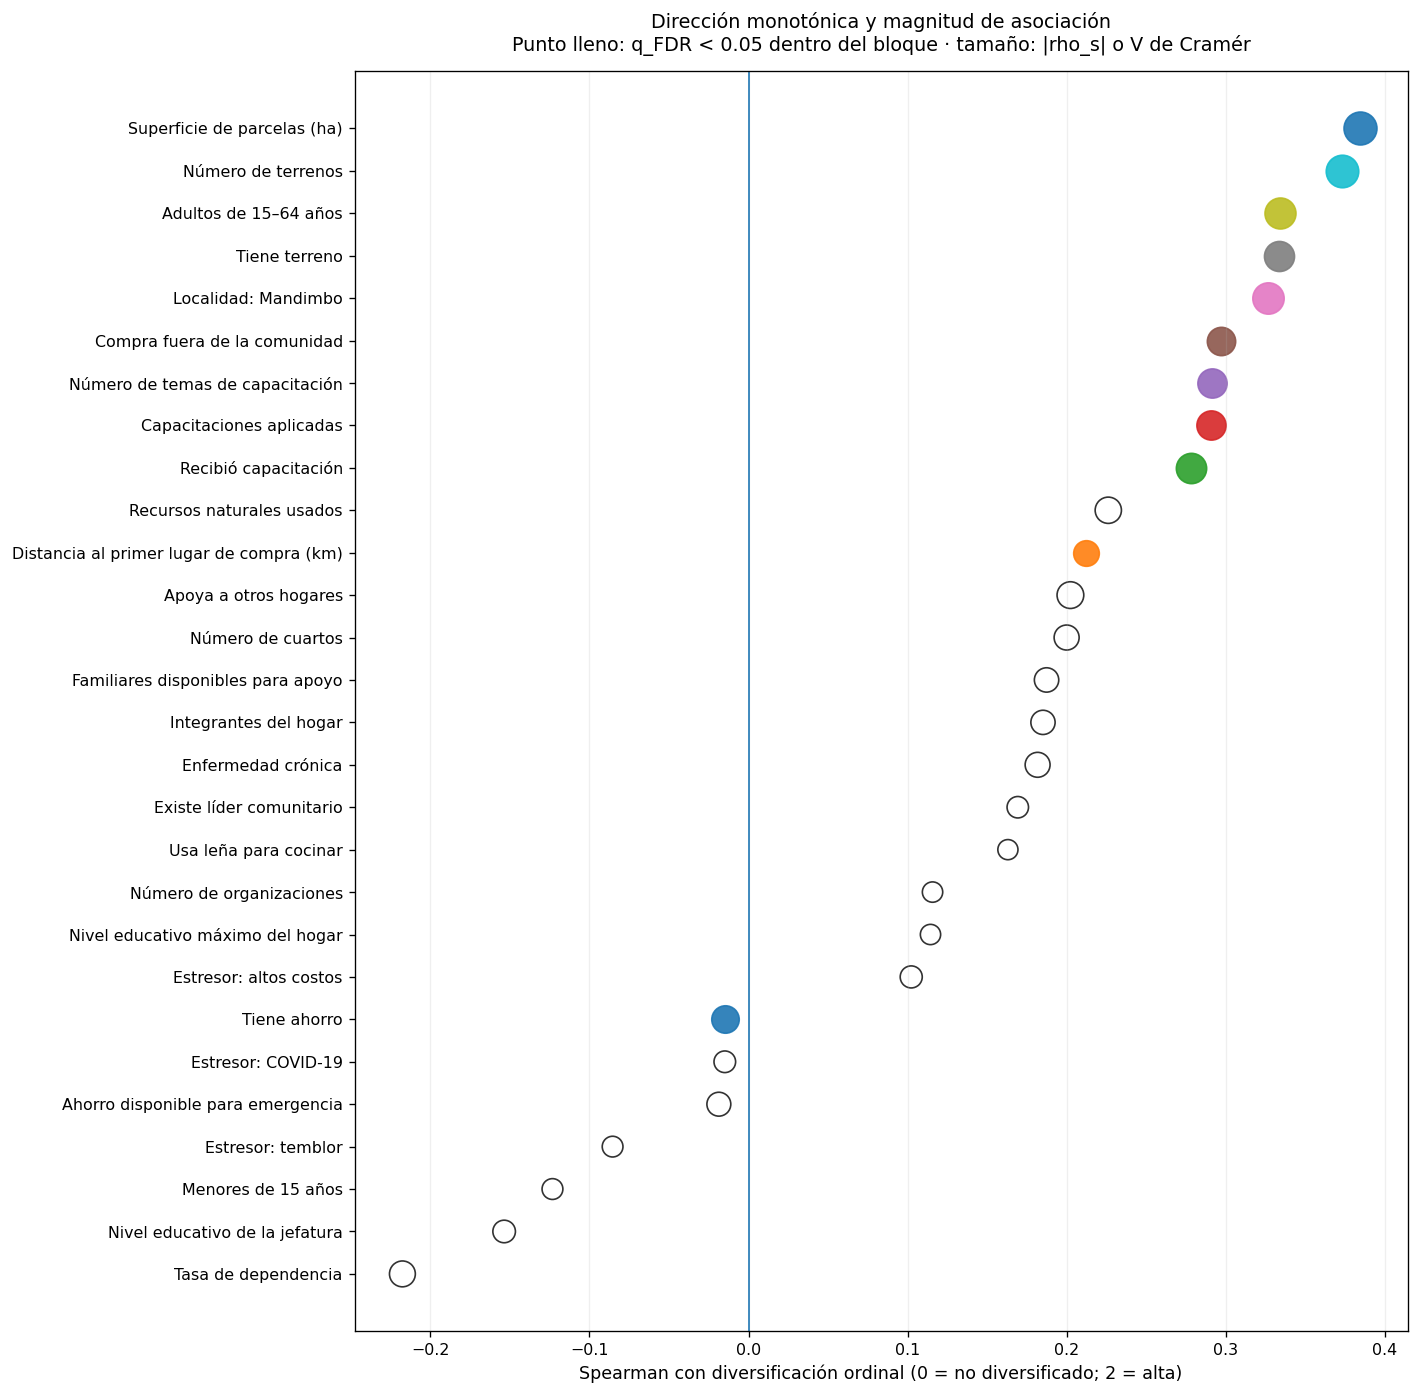

Lectura: las mayores asociaciones monotónicas positivas corresponden principalmente a superficie y número de terrenos, adultos de 15–64 años, tenencia de tierra, localidad y compra fuera de la comunidad. Tiene ahorro aparece como un punto relativamente grande cerca de rho_s = 0: no es ausencia de asociación, sino una forma no monotónica (45.7% → 17.0% → 41.5%) que V de Cramér sí recoge. Los puntos vacíos indican que la señal no permanece con q_FDR < 0.05 dentro de su bloque.


In [ ]:
# Represento dirección monotónica en el eje X y uso el tamaño del punto para conservar la magnitud general de asociación.
plot = resultados.copy()
plot["x"] = plot["rho_s"]
plot["tam"] = np.where(plot["Tipo"].eq("Binaria"), plot["V_Cramer"], plot["rho_s"].abs())
plot = plot.sort_values("tam", ascending=False).head(28).sort_values("x")

y = np.arange(len(plot))
fig, ax = plt.subplots(figsize=(13.5, 12.5))
ax.axvline(0, linewidth=1)
for i, (_, r) in enumerate(plot.iterrows()):
    size = 45 + 900 * float(r["tam"] if pd.notna(r["tam"]) else 0)
    if r["q_FDR"] < 0.05:
        ax.scatter(r["x"], i, s=size, marker="o", alpha=0.9)
    else:
        ax.scatter(r["x"], i, s=size, marker="o", facecolors="none", edgecolors="black", alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot["Indicador"], fontsize=9.5)
ax.set_xlabel("Spearman con diversificación ordinal (0 = no diversificado; 2 = alta)")
ax.set_title(
    "Dirección monotónica y magnitud de asociación\n"
    "Punto lleno: q_FDR < 0.05 dentro del bloque · tamaño: |rho_s| o V de Cramér",
    pad=12
)
ax.grid(axis="x", alpha=0.2)
fig.subplots_adjust(left=0.33, right=0.98, top=0.92, bottom=0.08)
plt.show()

print(
    "Lectura: las mayores asociaciones monotónicas positivas corresponden principalmente a superficie y número de terrenos, "
    "adultos de 15–64 años, tenencia de tierra, localidad y compra fuera de la comunidad. Tiene ahorro aparece como un punto "
    "relativamente grande cerca de rho_s = 0: no es ausencia de asociación, sino una forma no monotónica (45.7% → 17.0% → 41.5%) "
    "que V de Cramér sí recoge. Los puntos vacíos indican que la señal no permanece con q_FDR < 0.05 dentro de su bloque."
)


## 15. Visualización 2 — box/violin con jitter y tamaño efectivo de muestra

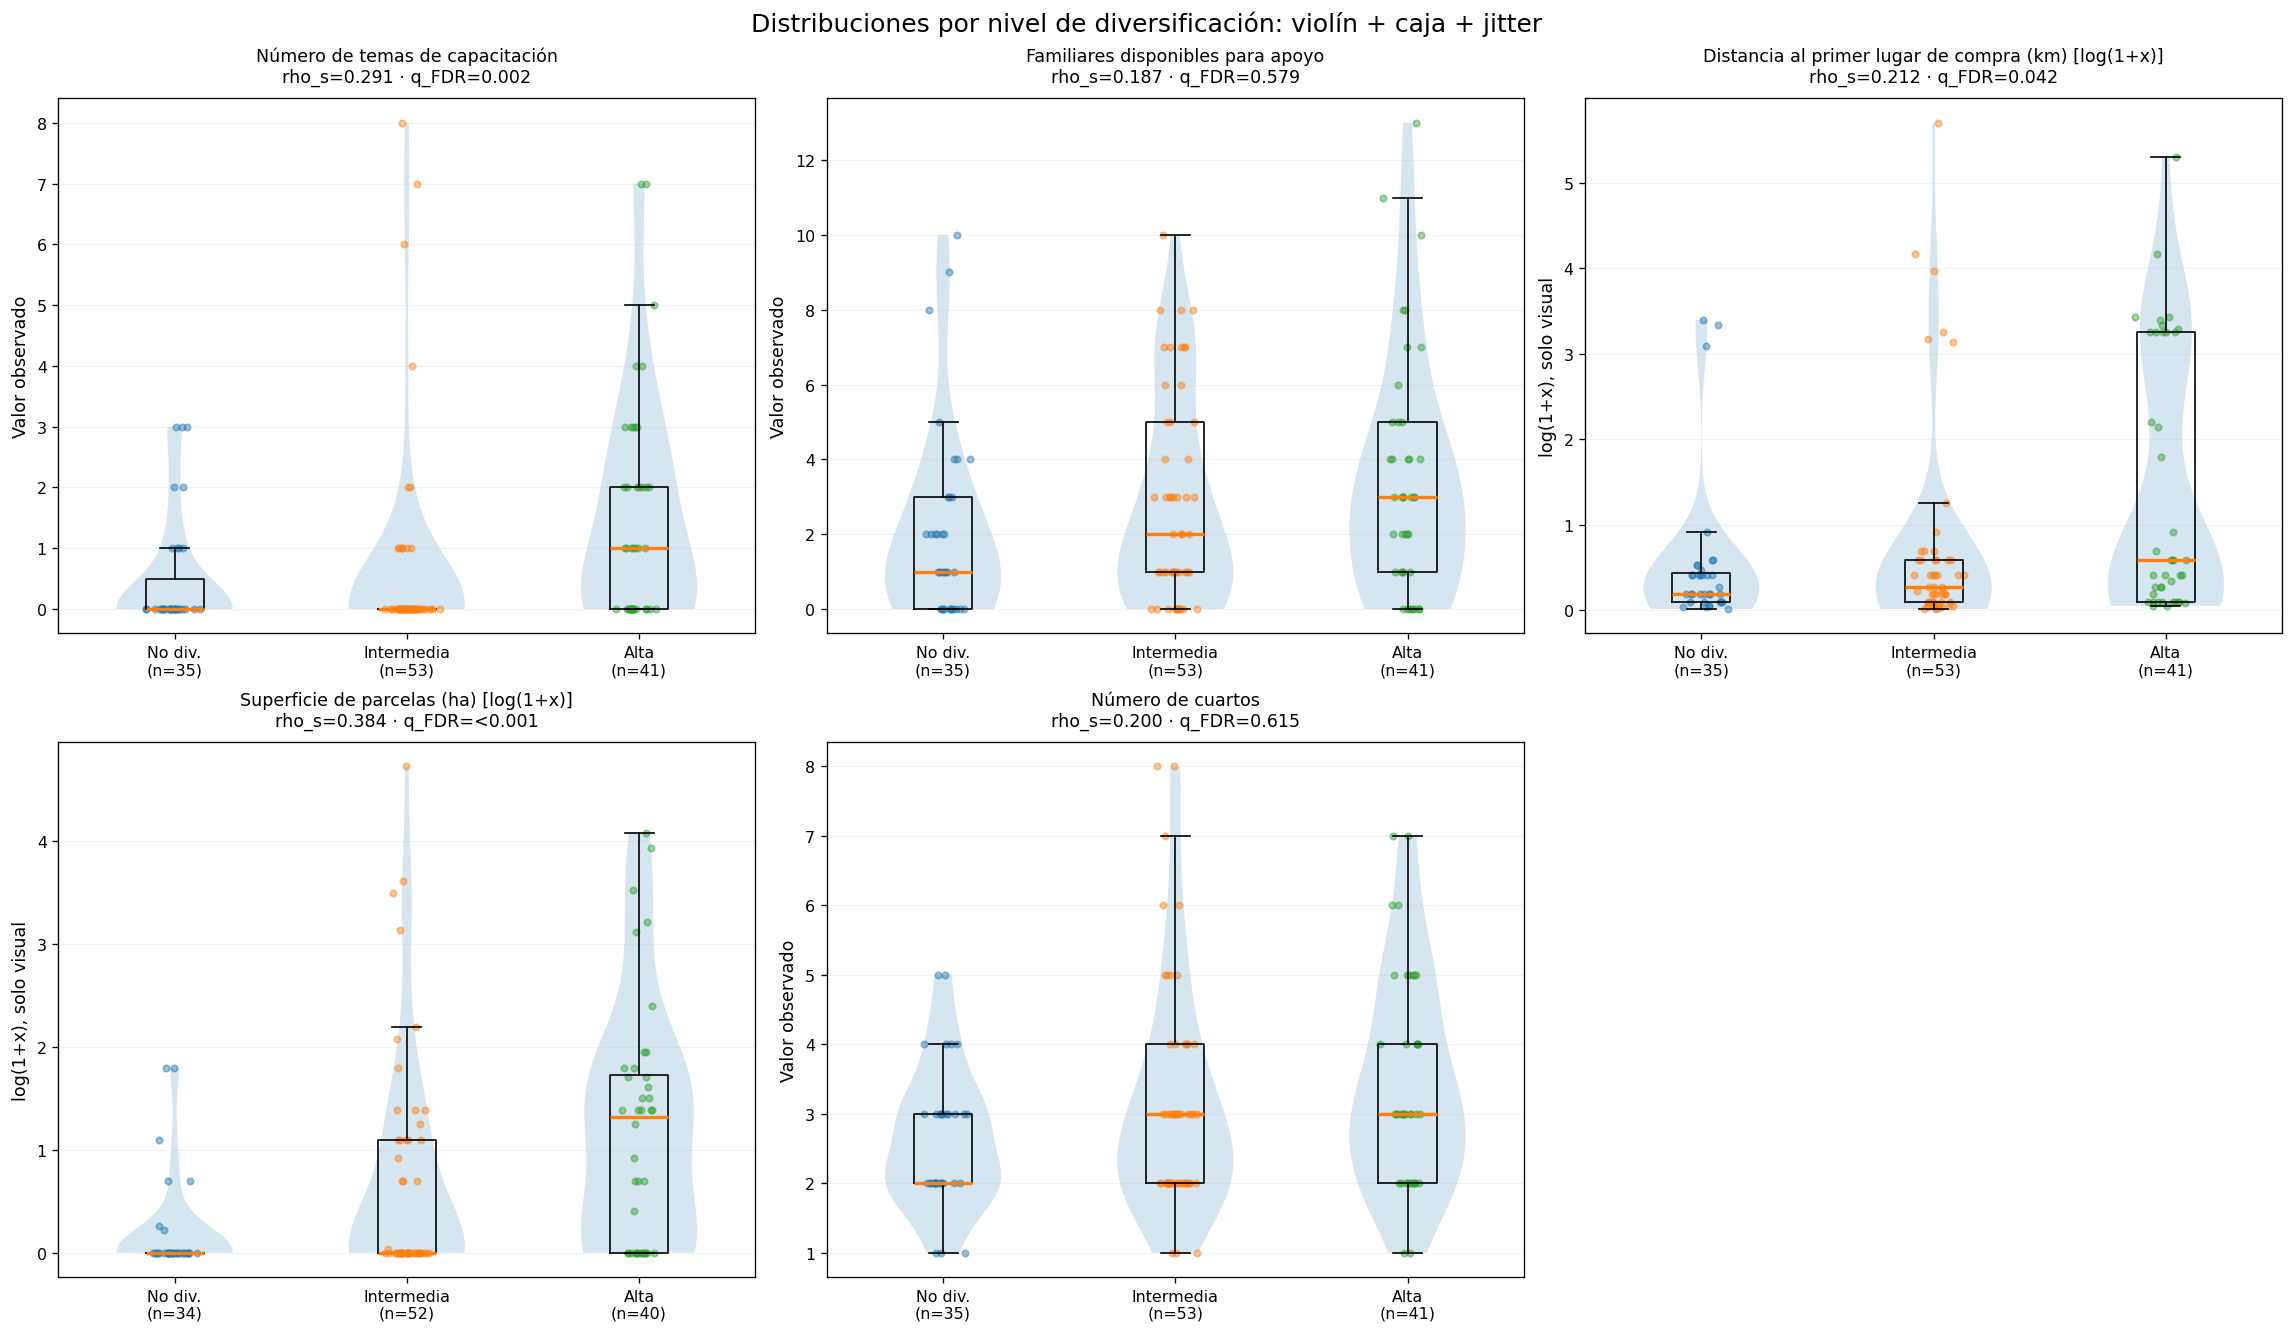

Lectura: el número de temas de capacitación se mantiene en mediana cero en los dos primeros niveles y aumenta en diversificación alta; los familiares disponibles para apoyo muestran un desplazamiento descriptivo gradual, aunque su q_FDR no es significativo; la distancia al primer lugar de compra y la superficie de parcelas son muy asimétricas, por lo que se muestran en log(1+x) únicamente para mejorar la lectura visual; sus pruebas se calcularon en la escala original. El número de cuartos exhibe diferencias pequeñas y no permanece significativo tras el ajuste del bloque físico.


In [ ]:
# Selecciono la variable numérica de mayor asociación en cada bloque de capital/conectividad con datos suficientes.
bloques_graf = ["Capital humano", "Capital social", "Conectividad territorial", "Capital natural", "Capital físico"]
seleccion = []
for b in bloques_graf:
    g = resultados[(resultados["Bloque"] == b) & (resultados["Tipo"] == "Numérica/ordinal")].copy()
    if not g.empty:
        g["m"] = g["rho_s"].abs()
        seleccion.append(g.sort_values("m", ascending=False).iloc[0]["Variable"])

n = len(seleccion)
fig, axes = plt.subplots(2, 3, figsize=(19, 11), constrained_layout=True)
axes = axes.ravel()
rng = np.random.default_rng(20260808)

for ax, v in zip(axes, seleccion):
    serie_total = pd.to_numeric(df[v], errors="coerce").dropna()
    transformar = (
        len(serie_total) > 5
        and serie_total.min() >= 0
        and serie_total.nunique() >= 10
        and abs(stats.skew(serie_total)) > 2
    )
    grupos_originales = [
        pd.to_numeric(df.loc[df["Diversificacion"] == g, v], errors="coerce").dropna().to_numpy()
        for g in ORDEN_DIV
    ]
    grupos = [np.log1p(a) if transformar else a for a in grupos_originales]
    pos = np.arange(1, 4)

    vp = ax.violinplot(grupos, positions=pos, showmeans=False, showmedians=False, showextrema=False)
    for body in vp["bodies"]:
        body.set_alpha(0.18)
    ax.boxplot(grupos, positions=pos, widths=0.25, showfliers=False, medianprops={"linewidth": 2})

    for j, arr in enumerate(grupos, start=1):
        jitter = rng.normal(j, 0.045, size=len(arr))
        ax.scatter(jitter, arr, s=15, alpha=0.45)

    fila = resultados.loc[resultados["Variable"] == v].iloc[0]
    qtxt = _ptexto(float(fila["q_FDR"]))
    titulo = ETIQUETAS.get(v, v) + (" [log(1+x)]" if transformar else "")
    ax.set_title(f"{titulo}\nrho_s={fila['rho_s']:.3f} · q_FDR={qtxt}", fontsize=10.5, pad=10)
    ax.set_xticks(pos)
    ax.set_xticklabels([
        f"No div.\n(n={len(grupos[0])})",
        f"Intermedia\n(n={len(grupos[1])})",
        f"Alta\n(n={len(grupos[2])})",
    ])
    ax.set_ylabel("log(1+x), solo visual" if transformar else "Valor observado")
    ax.grid(axis="y", alpha=0.15)

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("Distribuciones por nivel de diversificación: violín + caja + jitter", fontsize=15)
plt.show()

print(
    "Lectura: el número de temas de capacitación se mantiene en mediana cero en los dos primeros niveles y aumenta en diversificación alta; "
    "los familiares disponibles para apoyo muestran un desplazamiento descriptivo gradual, aunque su q_FDR no es significativo; "
    "la distancia al primer lugar de compra y la superficie de parcelas son muy asimétricas, por lo que se muestran en log(1+x) únicamente "
    "para mejorar la lectura visual; sus pruebas se calcularon en la escala original. El número de cuartos exhibe diferencias pequeñas y no "
    "permanece significativo tras el ajuste del bloque físico."
)


## 16. Visualización 3 — densidades superpuestas de variables continuas seleccionadas

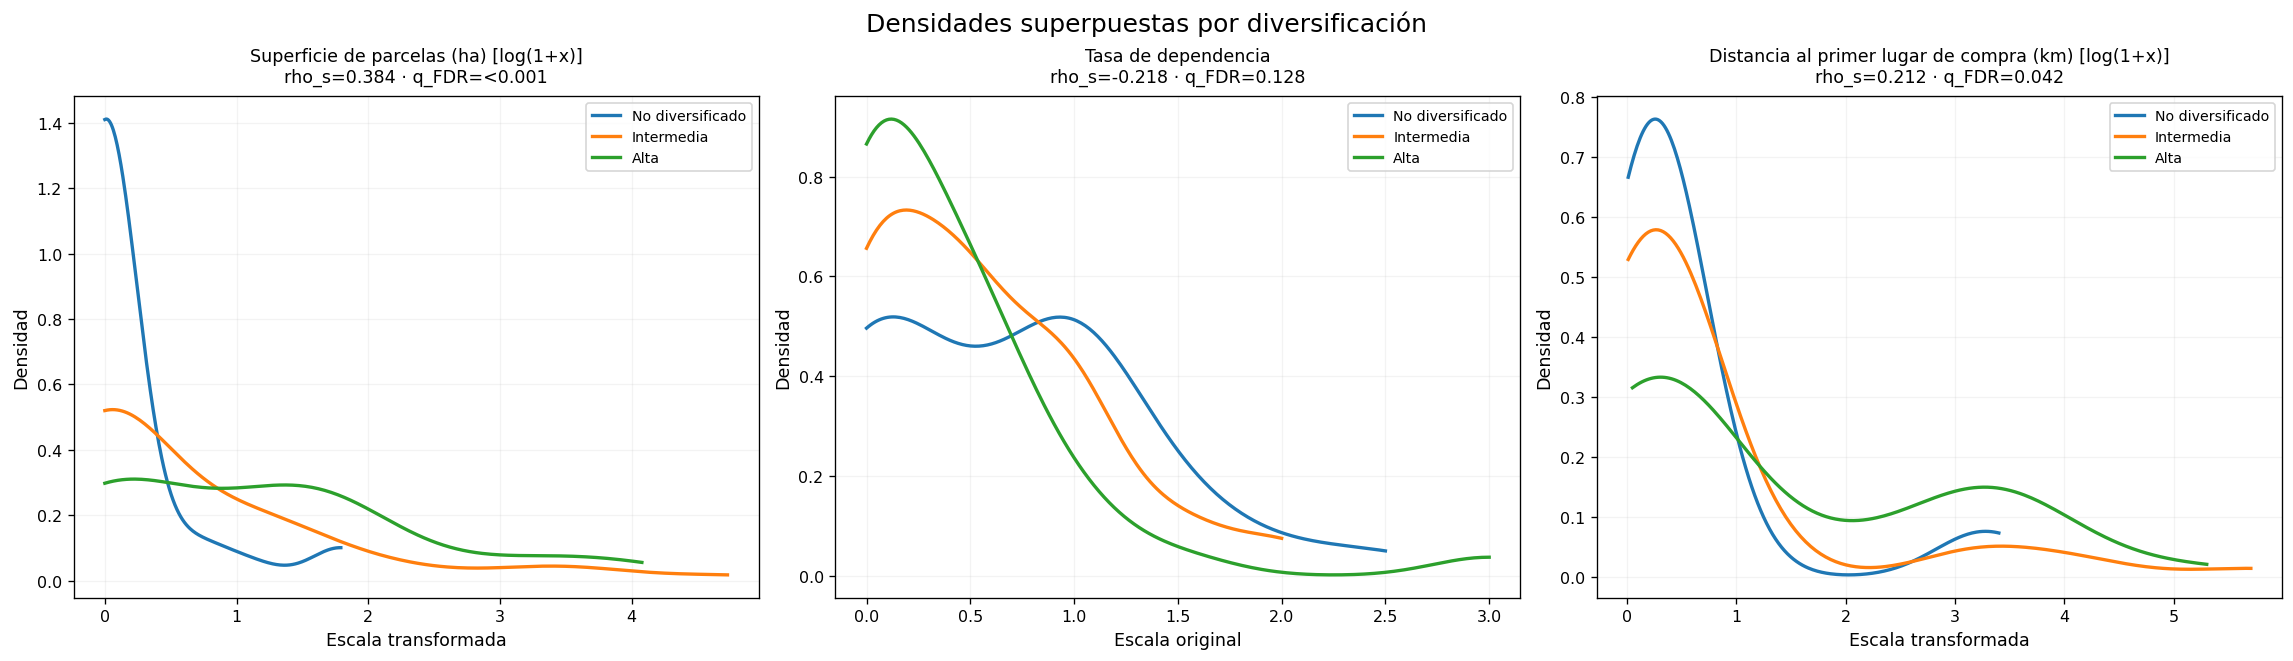

Lectura: la superficie de parcelas muestra el desplazamiento más claro hacia valores mayores en la categoría alta y conserva una asociación ajustada fuerte dentro de capital natural. La tasa de dependencia presenta una tendencia descriptiva inversa, pero no supera el ajuste FDR de covariables (q=0.128). La distancia al primer lugar de compra se desplaza hacia valores mayores en alta y conserva q_FDR < 0.05, aunque su marcada asimetría exige no resumirla con una media. Las transformaciones log(1+x) de la figura son exclusivamente visuales.


In [ ]:
# Selecciono automáticamente tres variables con al menos 10 valores distintos y mayor |rho_s|.
cand = resultados[(resultados["Tipo"] == "Numérica/ordinal")].copy()
cand["nunique"] = cand["Variable"].map(lambda v: df[v].nunique(dropna=True))
cand = cand[cand["nunique"] >= 10].copy()
cand["m"] = cand["rho_s"].abs()
vars_kde = cand.sort_values("m", ascending=False).head(3)["Variable"].tolist()

fig, axes = plt.subplots(1, len(vars_kde), figsize=(19, 5.4), constrained_layout=True)
if len(vars_kde) == 1:
    axes = [axes]
for ax, v in zip(axes, vars_kde):
    serie = pd.to_numeric(df[v], errors="coerce")
    transformar = serie.min(skipna=True) >= 0 and abs(stats.skew(serie.dropna())) > 2
    for g in ORDEN_DIV:
        arr = pd.to_numeric(df.loc[df["Diversificacion"] == g, v], errors="coerce").dropna().to_numpy()
        xarr = np.log1p(arr) if transformar else arr
        if len(np.unique(xarr)) > 1 and len(xarr) >= 5:
            kde = stats.gaussian_kde(xarr)
            xs = np.linspace(xarr.min(), xarr.max(), 250)
            ax.plot(xs, kde(xs), label=g, linewidth=2)
    fila = resultados.loc[resultados["Variable"] == v].iloc[0]
    suf = " [log(1+x)]" if transformar else ""
    ax.set_title(f"{ETIQUETAS.get(v,v)}{suf}\nrho_s={fila['rho_s']:.3f} · q_FDR={_ptexto(float(fila['q_FDR']))}", fontsize=10.5, pad=9)
    ax.set_xlabel("Escala transformada" if transformar else "Escala original")
    ax.set_ylabel("Densidad")
    ax.grid(alpha=0.15)
    ax.legend(fontsize=8.5)
fig.suptitle("Densidades superpuestas por diversificación", fontsize=15)
plt.show()

print(
    "Lectura: la superficie de parcelas muestra el desplazamiento más claro hacia valores mayores en la categoría alta y conserva una asociación "
    "ajustada fuerte dentro de capital natural. La tasa de dependencia presenta una tendencia descriptiva inversa, pero no supera el ajuste FDR "
    "de covariables (q=0.128). La distancia al primer lugar de compra se desplaza hacia valores mayores en alta y conserva q_FDR < 0.05, aunque "
    "su marcada asimetría exige no resumirla con una media. Las transformaciones log(1+x) de la figura son exclusivamente visuales."
)


## 17. Visualización 4 — dendrograma de perfiles por diversificación

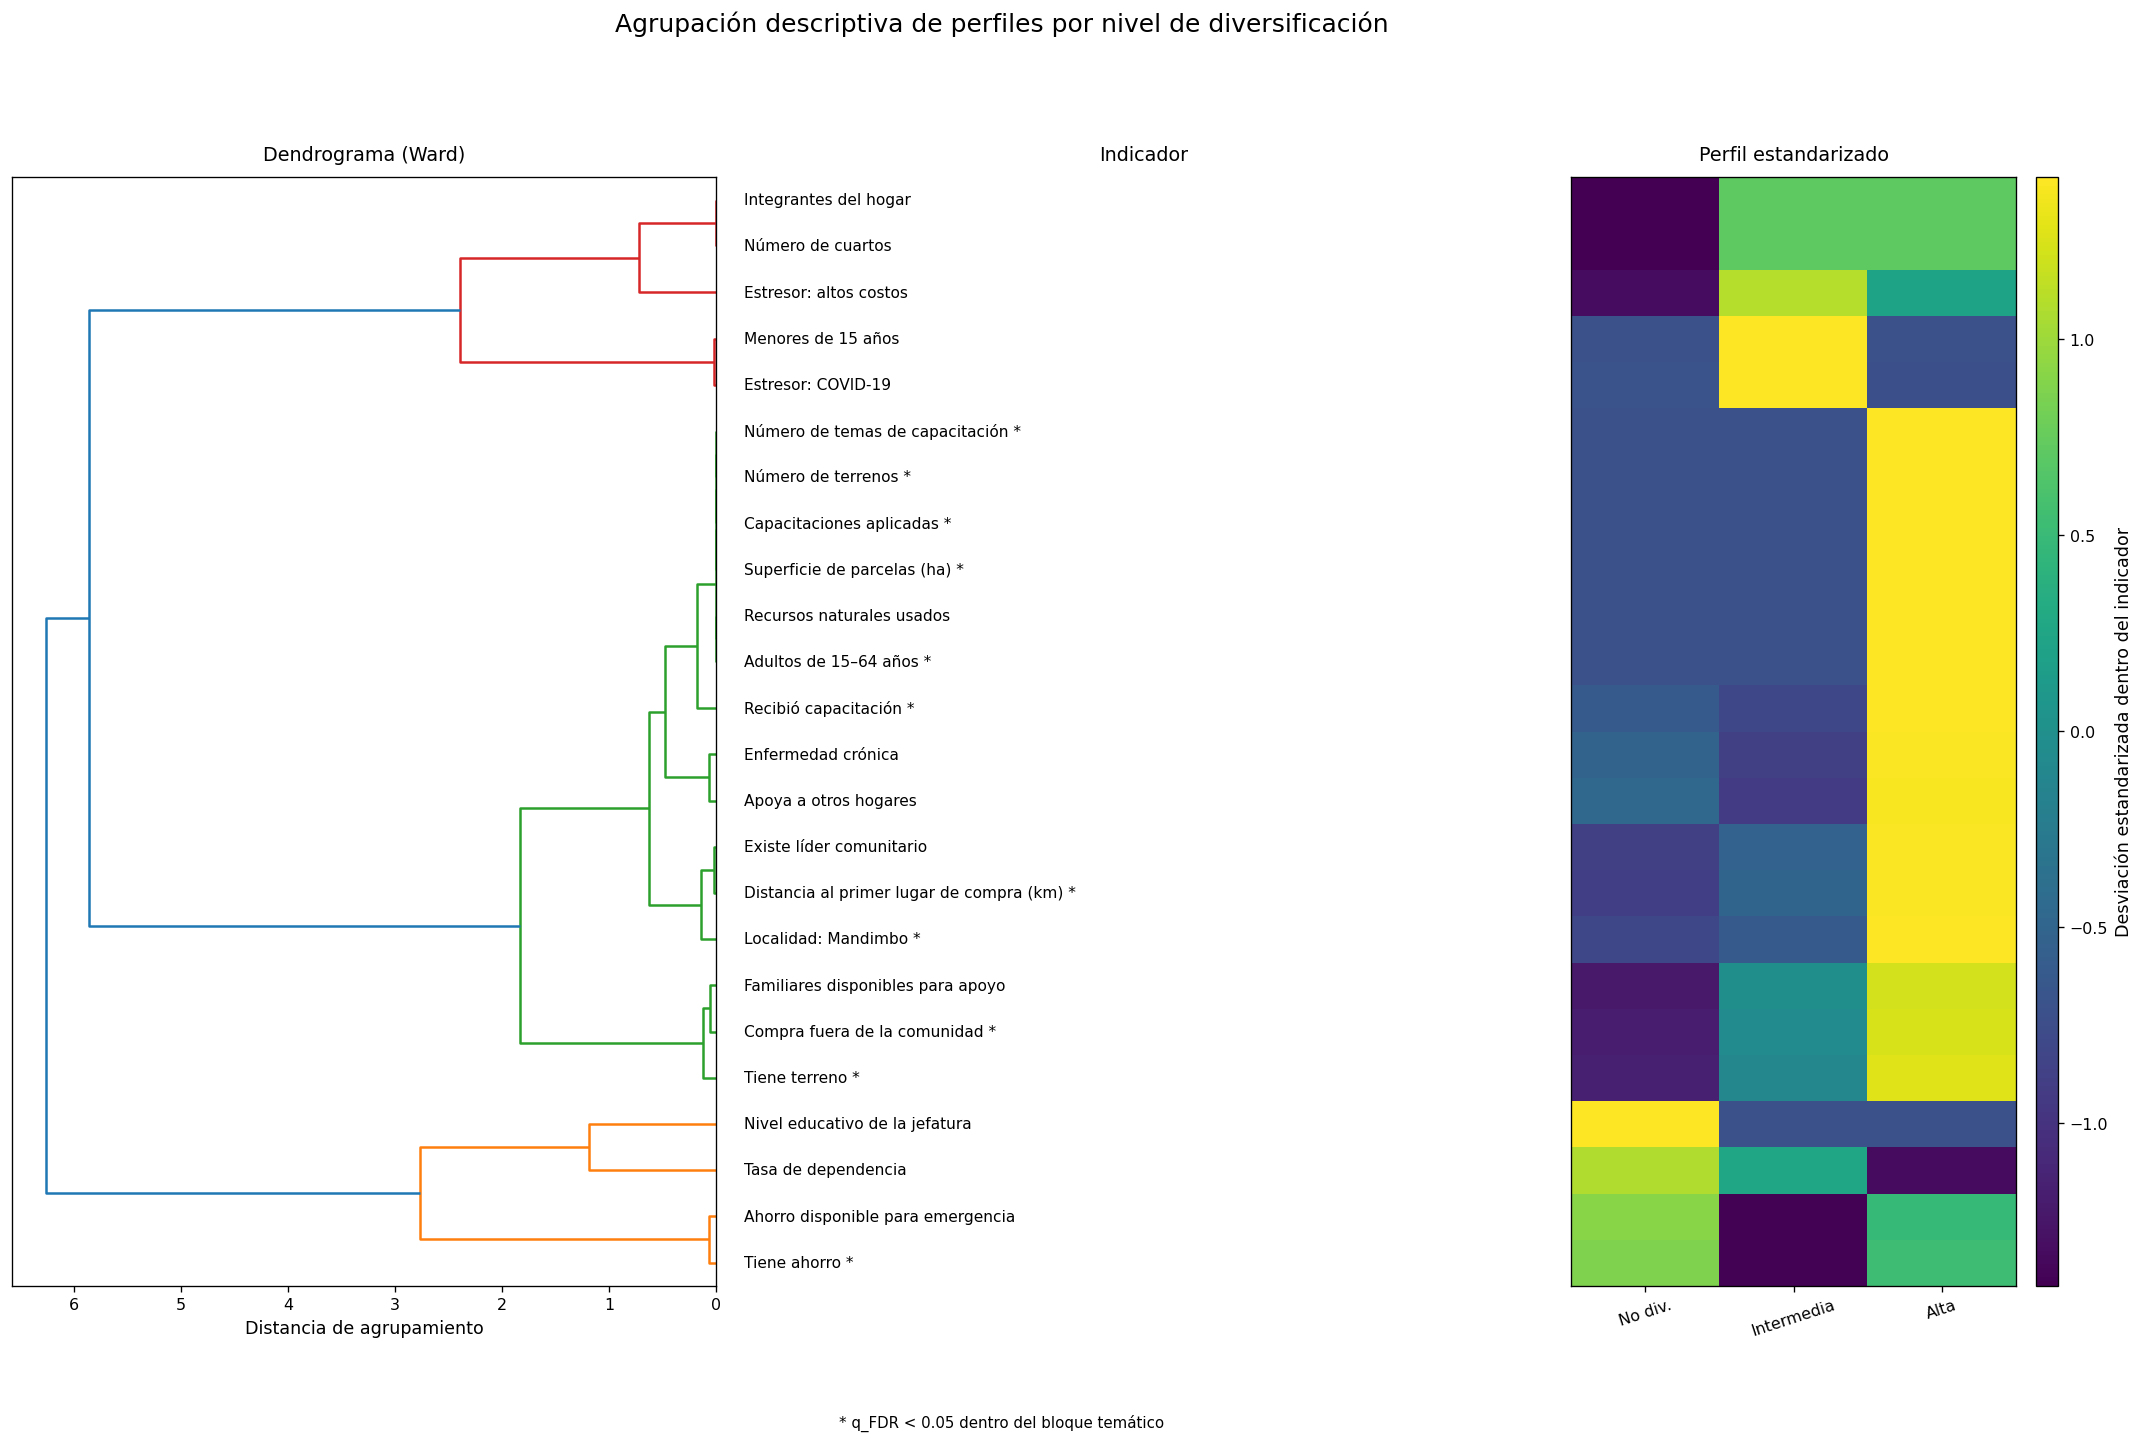

Lectura: el dendrograma agrupa indicadores por la semejanza de sus tres resúmenes estandarizados, no por correlaciones entre hogares. Por eso sirve para reconocer formas de respuesta —por ejemplo, perfiles que aumentan hacia diversificación alta o perfiles no monotónicos—, pero no demuestra colinealidad ni justifica combinar variables en un mismo índice. Los asteriscos identifican los indicadores que además mantienen q_FDR < 0.05 en su bloque; la proximidad de ramas sin asterisco sigue siendo únicamente descriptiva.


In [ ]:
# Construyo perfiles de tres puntos por variable: mediana para numéricas y prevalencia para binarias.
# La agrupación se basa en la forma del perfil entre No diversificado, Intermedia y Alta; no es una matriz de correlaciones entre predictores.
perf = []
for _, r in resultados.iterrows():
    v = r["Variable"]
    vals = []
    for g in ORDEN_DIV:
        s = pd.to_numeric(df.loc[df["Diversificacion"] == g, v], errors="coerce").dropna()
        vals.append(float(s.mean()) if r["Tipo"] == "Binaria" else float(s.median()))
    a = np.asarray(vals, dtype=float)
    if np.nanstd(a) == 0 or np.isnan(a).any():
        continue
    z = (a - a.mean()) / a.std(ddof=0)
    perf.append([v, ETIQUETAS.get(v, v), *z, float(r["Magnitud_asociacion"]), float(r["q_FDR"])])

prof = pd.DataFrame(
    perf,
    columns=["Variable", "Indicador", "No_div", "Intermedia", "Alta", "Magnitud", "q_FDR"]
)
prof = prof.sort_values("Magnitud", ascending=False).head(24).reset_index(drop=True)
X = prof[["No_div", "Intermedia", "Alta"]].to_numpy()
Z = linkage(X, method="ward")

fig = plt.figure(figsize=(22, 12))
gs = fig.add_gridspec(1, 4, width_ratios=[3.8, 4.4, 2.4, 0.12], wspace=0.04)
ax_d = fig.add_subplot(gs[0, 0])
ax_l = fig.add_subplot(gs[0, 1], sharey=ax_d)
ax_h = fig.add_subplot(gs[0, 2], sharey=ax_d)
ax_c = fig.add_subplot(gs[0, 3])

d = dendrogram(Z, orientation="left", no_labels=True, ax=ax_d)
orden = d["leaves"]
n_hojas = len(orden)
ypos = 5 + 10 * np.arange(n_hojas)

ax_d.set_title("Dendrograma (Ward)", pad=10)
ax_d.set_xlabel("Distancia de agrupamiento")
ax_d.tick_params(axis="y", left=False, labelleft=False)

# Reservo un eje exclusivo para los nombres; así no se superponen con el mapa de perfiles.
ax_l.set_xlim(0, 1)
ax_l.set_ylim(ax_d.get_ylim())
ax_l.axis("off")
for y, idx in zip(ypos, orden):
    marca = " *" if prof.loc[idx, "q_FDR"] < 0.05 else ""
    ax_l.text(0.01, y, prof.loc[idx, "Indicador"] + marca, va="center", ha="left", fontsize=9.2)
ax_l.set_title("Indicador", pad=10)

im = ax_h.imshow(
    X[orden], aspect="auto", interpolation="nearest", origin="lower",
    extent=(-0.5, 2.5, 0, 10 * n_hojas)
)
ax_h.set_ylim(ax_d.get_ylim())
ax_h.set_xticks([0, 1, 2])
ax_h.set_xticklabels(["No div.", "Intermedia", "Alta"], rotation=18)
ax_h.tick_params(axis="y", left=False, labelleft=False)
ax_h.set_title("Perfil estandarizado", pad=10)
cb = fig.colorbar(im, cax=ax_c)
cb.set_label("Desviación estandarizada dentro del indicador")

fig.suptitle("Agrupación descriptiva de perfiles por nivel de diversificación", fontsize=15, y=0.995)
fig.text(0.5, 0.012, "* q_FDR < 0.05 dentro del bloque temático", ha="center", fontsize=9)
plt.show()

print(
    "Lectura: el dendrograma agrupa indicadores por la semejanza de sus tres resúmenes estandarizados, no por correlaciones entre hogares. "
    "Por eso sirve para reconocer formas de respuesta —por ejemplo, perfiles que aumentan hacia diversificación alta o perfiles no monotónicos—, "
    "pero no demuestra colinealidad ni justifica combinar variables en un mismo índice. Los asteriscos identifican los indicadores que además "
    "mantienen q_FDR < 0.05 en su bloque; la proximidad de ramas sin asterisco sigue siendo únicamente descriptiva."
)


## 18. Visualización 5 — perfiles de prevalencia para asociaciones binarias principales

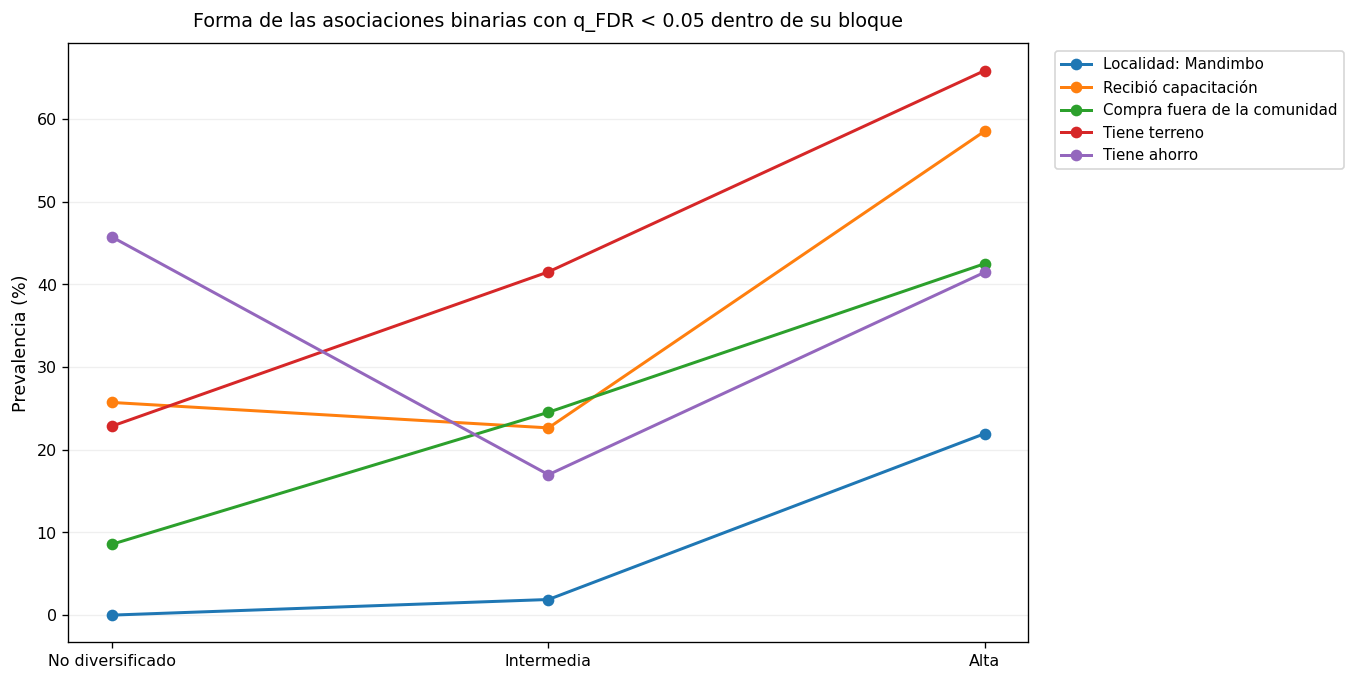

Lectura: tenencia de tierra, compra fuera de la comunidad y pertenencia a Mandimbo aumentan hacia la categoría alta. La capacitación no sigue un gradiente continuo: no diversificados e intermedios son semejantes y la prevalencia aumenta con fuerza en alta. El ahorro es el patrón distinto: cae en la categoría intermedia y vuelve a niveles próximos a los no diversificados en alta. Esta heterogeneidad desaconseja resumir todas las variables binarias mediante una única pendiente ordinal.


In [ ]:
# Muestro la forma de las asociaciones binarias que permanecen con q_FDR < 0.05.
bins = resultados[(resultados["Tipo"] == "Binaria") & (resultados["q_FDR"] < 0.05)].copy()
if bins.empty:
    print("No hay asociaciones binarias con q_FDR < 0.05 para graficar.")
else:
    fig, ax = plt.subplots(figsize=(12.5, 6.4))
    x = np.arange(3)
    for _, r in bins.iterrows():
        v = r["Variable"]
        prev = [100 * pd.to_numeric(df.loc[df["Diversificacion"] == g, v], errors="coerce").mean() for g in ORDEN_DIV]
        ax.plot(x, prev, marker="o", linewidth=1.8, label=r["Indicador"])
    ax.set_xticks(x)
    ax.set_xticklabels(ORDEN_DIV)
    ax.set_ylabel("Prevalencia (%)")
    ax.set_title("Forma de las asociaciones binarias con q_FDR < 0.05 dentro de su bloque", pad=10)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    fig.subplots_adjust(left=0.09, right=0.73, top=0.90, bottom=0.12)
    plt.show()
    print(
        "Lectura: tenencia de tierra, compra fuera de la comunidad y pertenencia a Mandimbo aumentan hacia la categoría alta. "
        "La capacitación no sigue un gradiente continuo: no diversificados e intermedios son semejantes y la prevalencia aumenta con fuerza en alta. "
        "El ahorro es el patrón distinto: cae en la categoría intermedia y vuelve a niveles próximos a los no diversificados en alta. "
        "Esta heterogeneidad desaconseja resumir todas las variables binarias mediante una única pendiente ordinal."
    )


## 19. Notas para las fases posteriores

- Los resultados sirven para **seleccionar, revisar y justificar** componentes potenciales; no sustituyen la construcción conceptual de los capitales.
- La significación bivariada no será un filtro automático de inclusión. Capital social, capital físico y vulnerabilidad no muestran asociaciones ajustadas en esta fase, pero ello no autoriza a eliminar sus componentes si existe fundamento conceptual.
- Las variables de capacitación merecen atención por su concentración en hogares con diversificación alta, aunque la dirección temporal es incierta: la capacitación puede facilitar la diversificación, pero hogares ya diversificados también pueden acceder con mayor frecuencia a capacitación.
- Tierra presenta las asociaciones de mayor magnitud. En el modelado posterior deberá distinguirse su papel como dotación natural de cualquier relación estructural con la posibilidad de realizar actividades primarias.
- La conectividad parece diferenciarse principalmente por acceso a circuitos externos —comprar fuera— y no por una mayor distancia entre quienes ya compran fuera.
- El ahorro exige una especificación que permita no linealidad o categorías, porque su patrón es claramente no monotónico.
- Mandimbo debe mantenerse en la muestra general: 9 de sus 10 hogares aparecen en diversificación alta y el tamaño disponible no sostiene un modelo territorial separado.
- No se detectó concentración diferencial de faltantes por nivel de diversificación después del ajuste FDR, pero cada modelo posterior deberá informar su tamaño efectivo de muestra.
- Antes de construir capitales deberá revisarse redundancia entre componentes con criterios sustantivos y estadísticos; el dendrograma de esta fase describe perfiles frente a la diversificación y **no** constituye por sí mismo una prueba de colinealidad.